# Import

In [1]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

import joblib
import numpy as np

In [2]:
from physics.Iso_data_handler import Iso_data_handler
from physics.Data_visualiser import Data_visualiser
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator

In [3]:
pre_path = "../../../../../../"
physical_model = "PARSEC"
path_to_data = pre_path + "data/PARSEC/"
path_to_results = pre_path + "results/model_A_partial/final_models/"
path_to_predictions = pre_path + "predictions/model_A_partial/final_models/"
path_to_models = 'model/final_models/Model_A_partial/PARSEC/'
output_parameters = ["mass", "radius"]
categories_name = ["label"]

In [4]:
override = False
use_preds = True
save = True
show = True

input_col_names = ['$\log(age)$', '$\log(T_{\mathrm{eff}})$', '$\log(g)$', '$[\mathrm{Fe/H}]$']
output_col_names = ['mass', 'radius']

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\m'
C:\Users\antoi\AppData\Local\Temp\ipykernel_9960\4118818034.py:6: SyntaxWarning: invalid escape sequence '\l'
  input_col_names = ['$\log(age)$', '$\log(T_{\mathrm{eff}})$', '$\log(g)$', '$[\mathrm{Fe/H}]$']
C:\Users\antoi\AppData\Local\Temp\ipykernel_9960\4118818034.py:6: SyntaxWarning: invalid escape sequence '\l'
  input_col_names = ['$\log(age)$', '$\log(T_{\mathrm{eff}})$', '$\log(g)$', '$[\mathrm{Fe/H}]$']
C:\Users\antoi\AppData\Local\Temp\ipykernel_9960\4118818034.py:6: SyntaxWarning: invalid escape sequence '\l'
  input_col_names = ['$\log(age)$', '$\log(T_{\mathrm{eff}})$', '$\log(g)$

# Data preparation

In [6]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['logAge', 'logTe', 'logg', 'label', 'metallicity', 'Mass', 'Rpol'], 
                              physical_model, rescale=True)

iso_df = iso_handler.get_isochrone_dataframe()

Reading PARSEC dataframe from PARSEC_rescaled_iso_full_data.csv file...


In [7]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'label':[1, 2, 3, 4, 5, 6]})

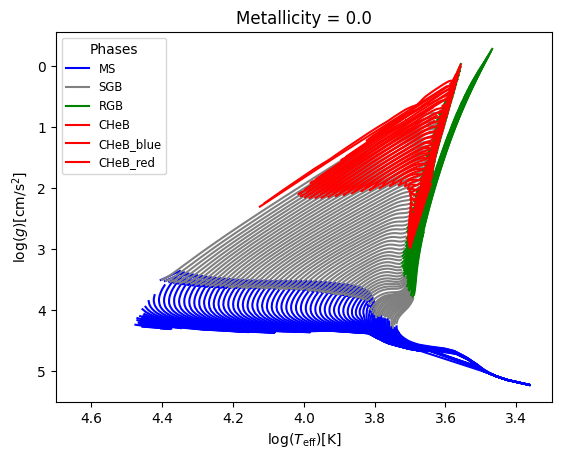

In [11]:
data_visualiser_phase_filtered = Data_visualiser(phase_filtered_iso_df, physical_model)
data_visualiser_phase_filtered.plot_Kiel([], [0.0], x_lim=(4.7, 3.3))

In [8]:
X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs = \
    Data_preparator.split_data(phase_filtered_iso_df, x_cols=['logAge', 'logTe', 'logg', 'metallicity'], 
                               y_cols=['Mass', 'Rpol'], categories_cols=['label'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)
print(categories_train.shape, categories_ivs.shape)

Training set statistics:
Range in train data for the Mass parameter : 0.09 - 13.943
Median value in train data for the Mass parameter: 1.427
Mean value in train data for the Mass parameter: 2.674483292715276

Range in train data for the Rpol parameter : -0.9763360818022064 - 2.8372727025023003
Median value in train data for the Rpol parameter: 1.015778756389041
Mean value in train data for the Rpol parameter: 0.9646120024510401

Testing set statistics:
Range in test data for the Mass parameter : 0.09 - 13.952
Median value in test data for the Mass parameter: 1.43
Mean value in test data for the Mass parameter: 2.6664658683974936

Range in test data for the Rpol parameter : -0.9763360818022064 - 2.831997677235896
Median value in test data for the Rpol parameter: 1.015778756389041
Mean value in test data for the Rpol parameter: 0.9652648999427869

(241272, 4) (80424, 4)
(241272, 2) (80424, 2)
(241272, 1) (80424, 1)


In [9]:
X_train_standard, X_ivs_standard = Data_preparator.scale_data(X_train, X_ivs, "standard")
X_train_quantile, X_ivs_quantile = Data_preparator.scale_data(X_train, X_ivs, "quantile")

# Getting the final evaluations

## Random forest

In [10]:
tag = "Base"


Base train data :
Evaluating predictions...
0.0

mass results for the label category with a value of 1.0
  value range :  0.09 - 13.952
  RVE :  0.9999369941317571
  RMSE :  0.024277447239483795
  MAE :  0.006406045724917477
  MedAE :  0.000587499999998714
  CORR :  0.999968596908455
  MAX_ER :  0.817184999999963
  Percentiles : 
    75th percentile :  0.0033724999999515948
    90th percentile :  0.014841750000004691
    95th percentile :  0.0312328749999842
    99th percentile :  0.09279944999999516

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.999956325744368
  RMSE :  0.02189713028814248
  MAE :  0.008245304172309882
  MedAE :  0.0015325000000028233
  CORR :  0.9999781757054518
  MAX_ER :  0.37533750000002364
  Percentiles : 
    75th percentile :  0.008273125000001658
    90th percentile :  0.021847750000009068
    95th percentile :  0.034557249999999935
    99th percentile :  0.08965920000000416

mass results for the label cat

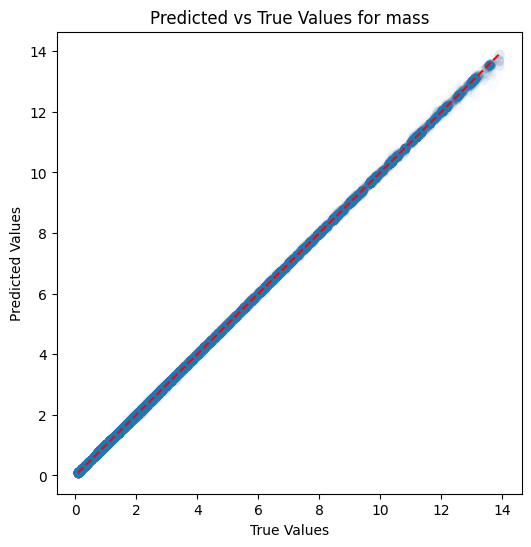

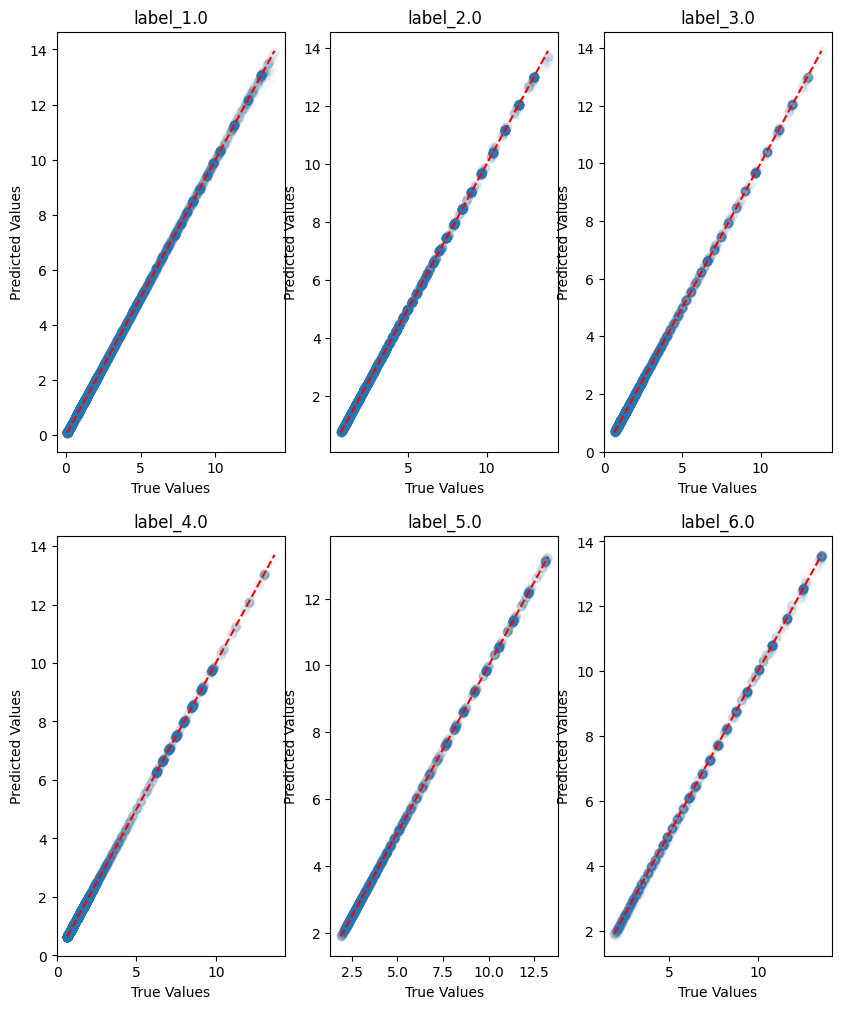

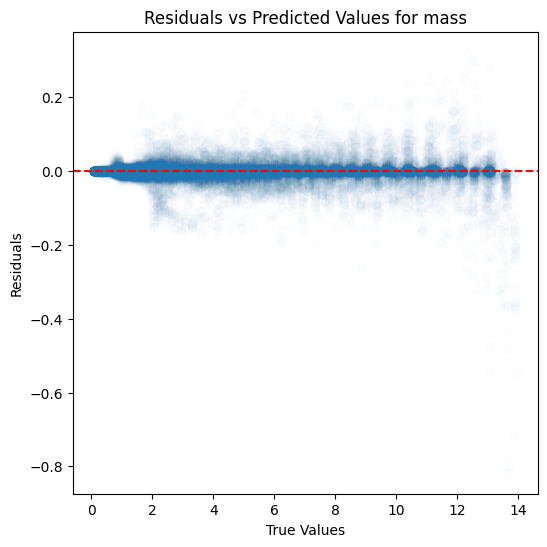

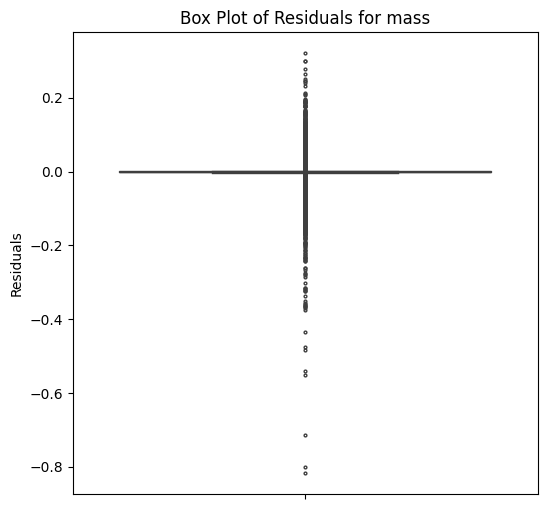

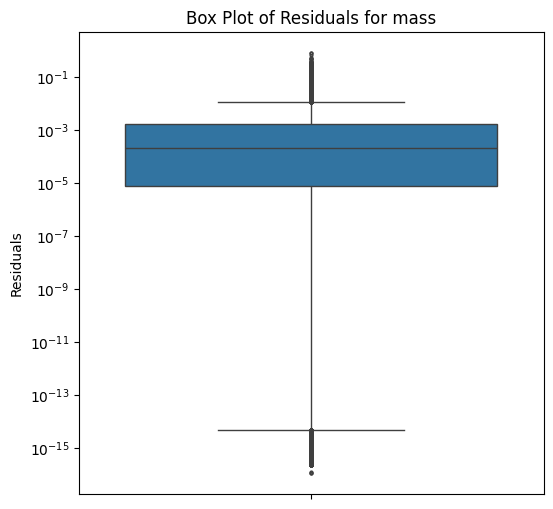

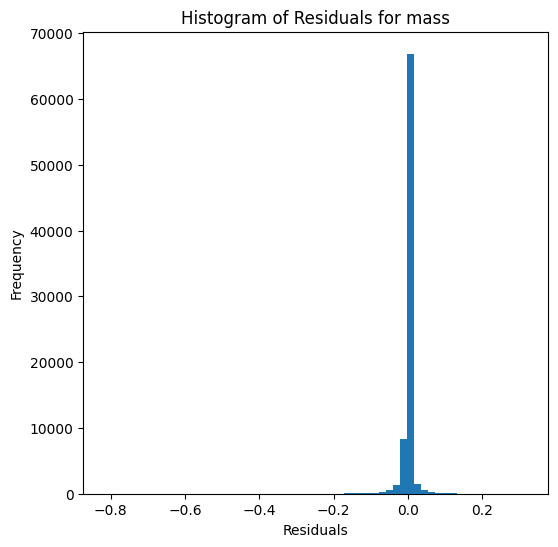

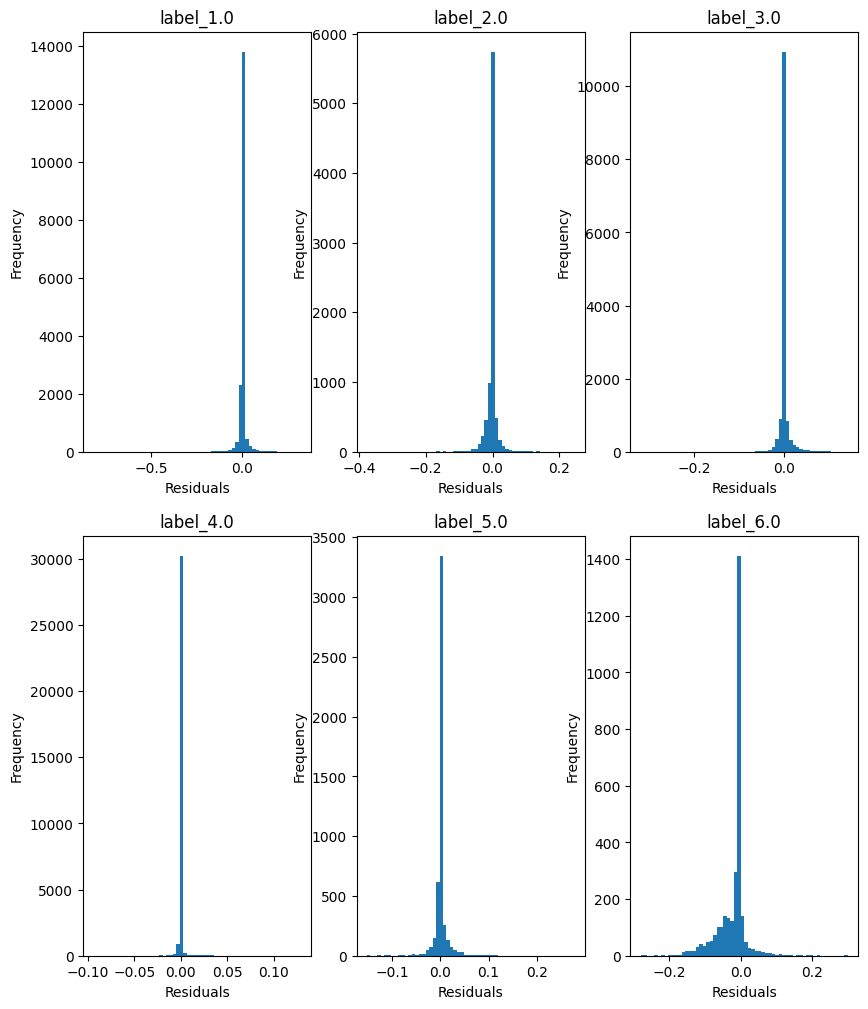

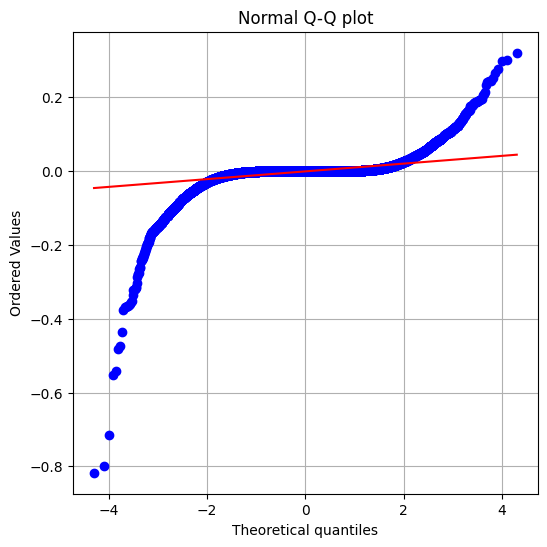

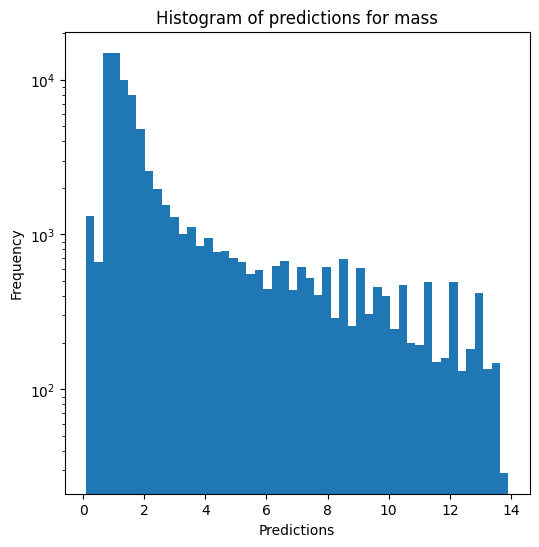

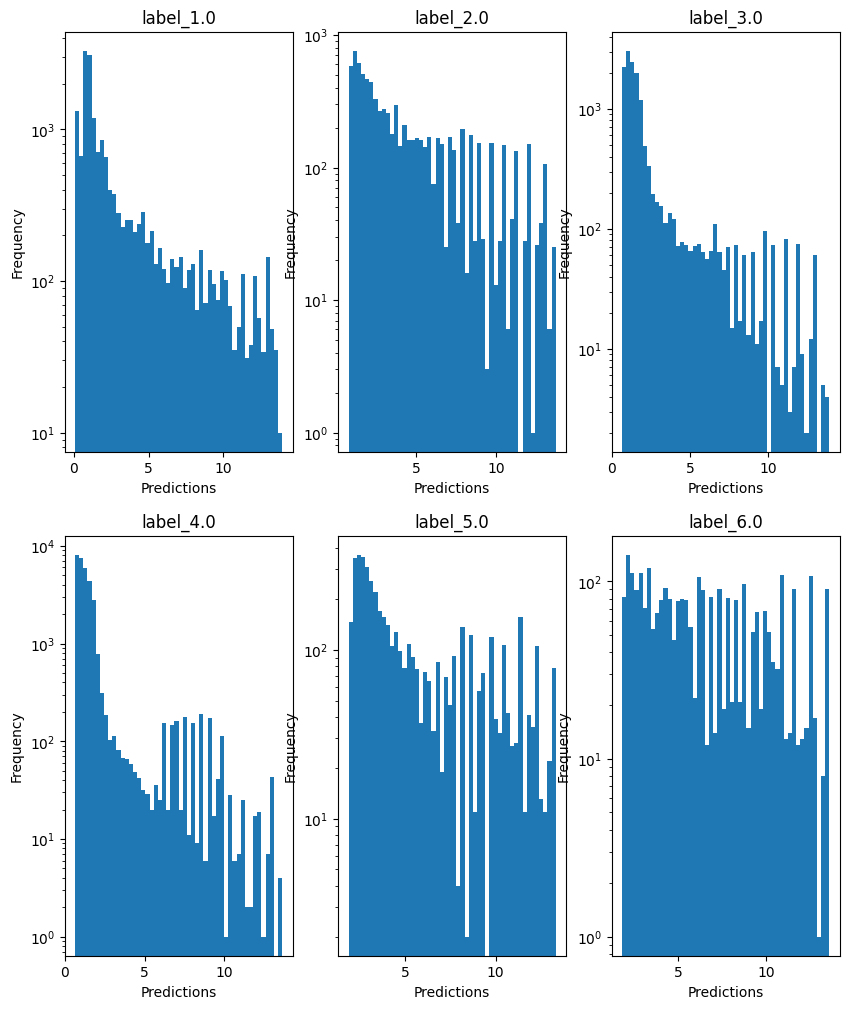

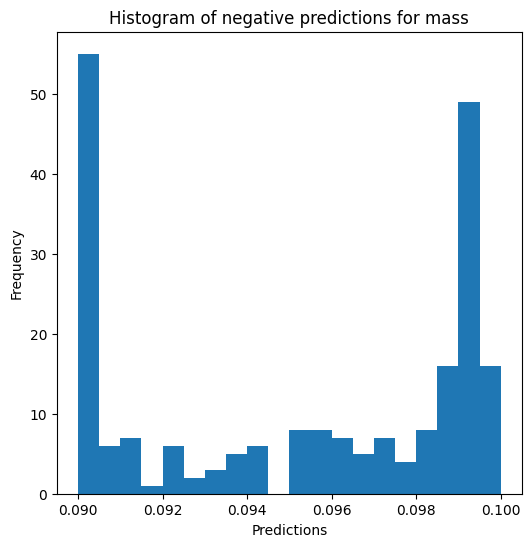

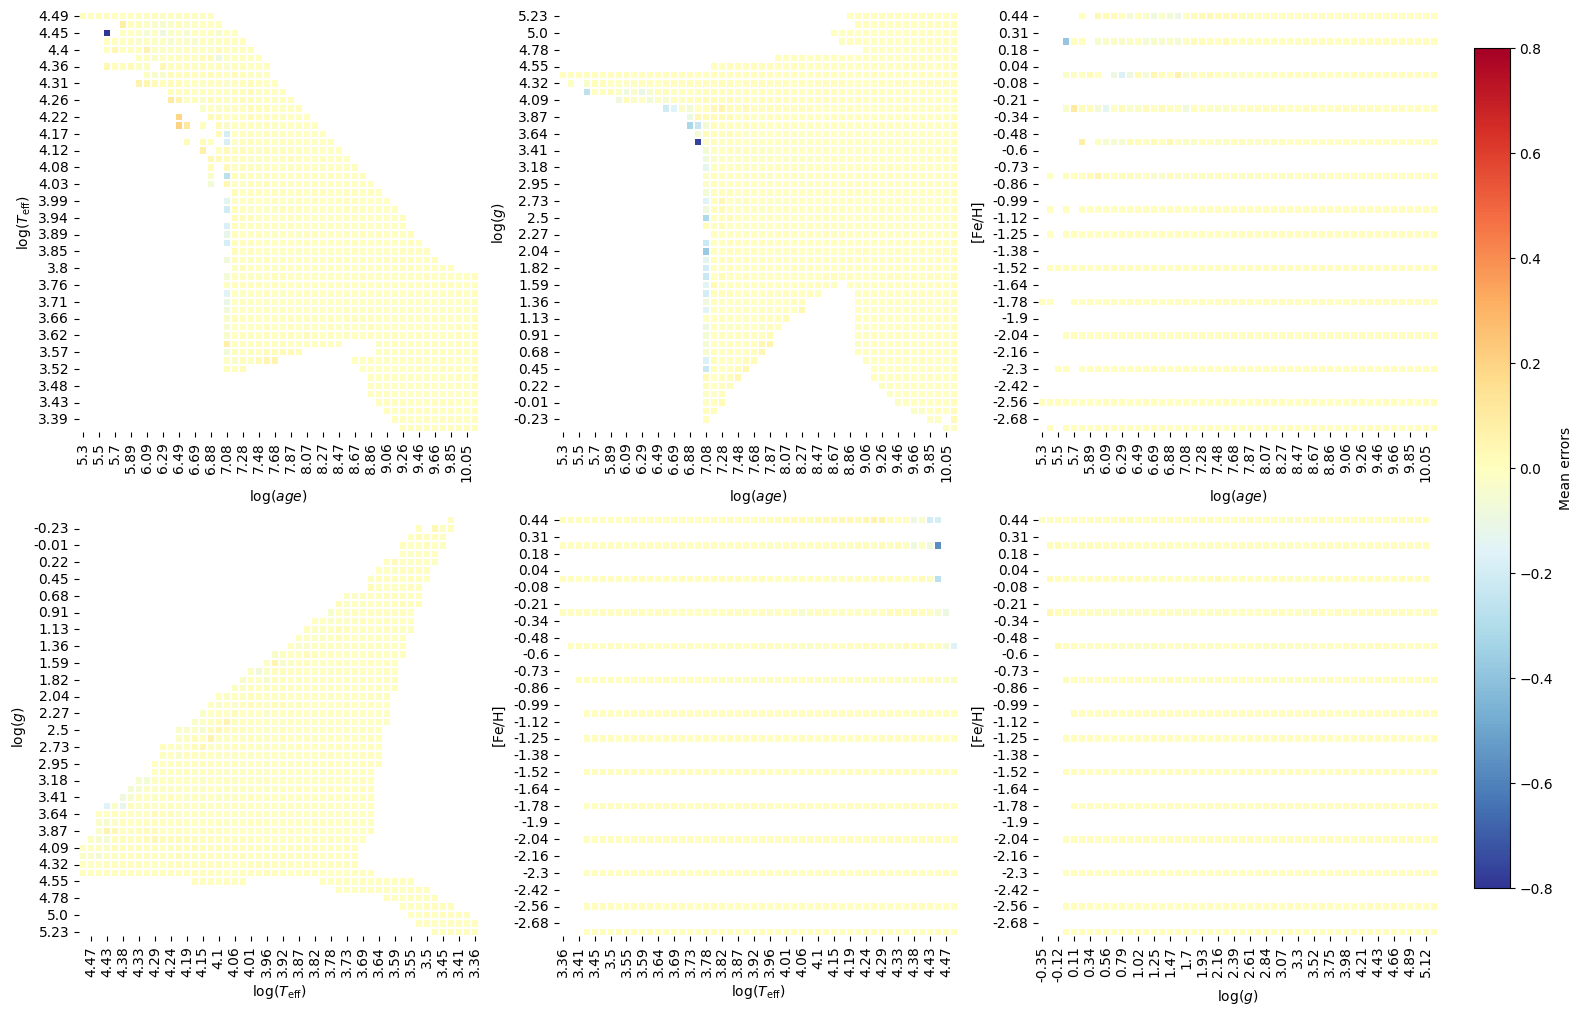

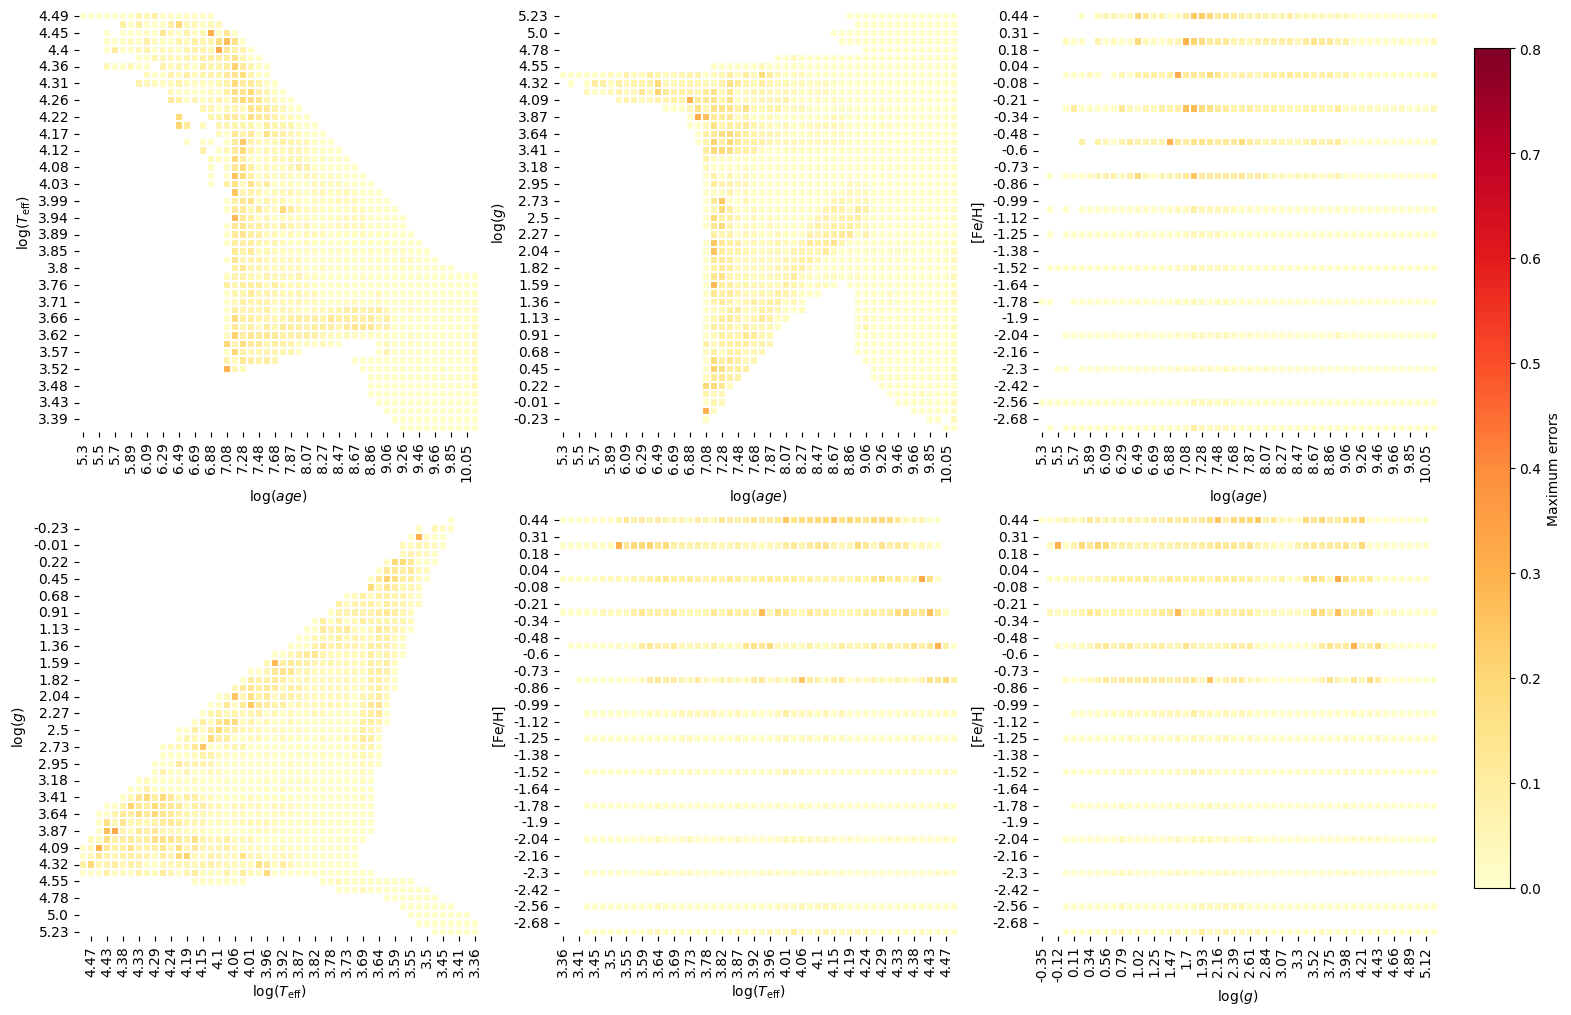

0.0

radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.165244326125311
  RVE :  0.9999578966930978
  RMSE :  0.00240021615662336
  MAE :  0.0010231547233010042
  MedAE :  0.0002452626877263303
  CORR :  0.9999790855772797
  MAX_ER :  0.041077987708993624
  Percentiles : 
    75th percentile :  0.0009506733460612829
    90th percentile :  0.0028318666658464432
    95th percentile :  0.004622714608541989
    99th percentile :  0.010728506098407854

radius results for the label category with a value of 2.0
  value range :  0.0366288953621611 - 2.443262987458695
  RVE :  0.9998773902307079
  RMSE :  0.006057122901846332
  MAE :  0.002374289298376651
  MedAE :  0.0006097736715632018
  CORR :  0.999946568323441
  MAX_ER :  0.127788371674455
  Percentiles : 
    75th percentile :  0.002213836134045938
    90th percentile :  0.006246596151103053
    95th percentile :  0.010207101253076193
    99th percentile :  0.023327936625689244

radius resul

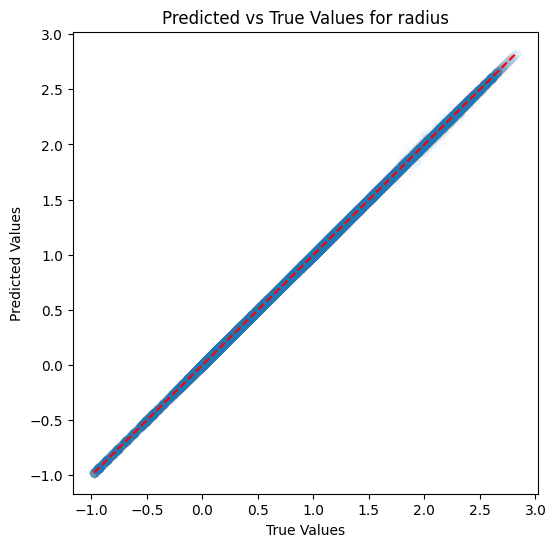

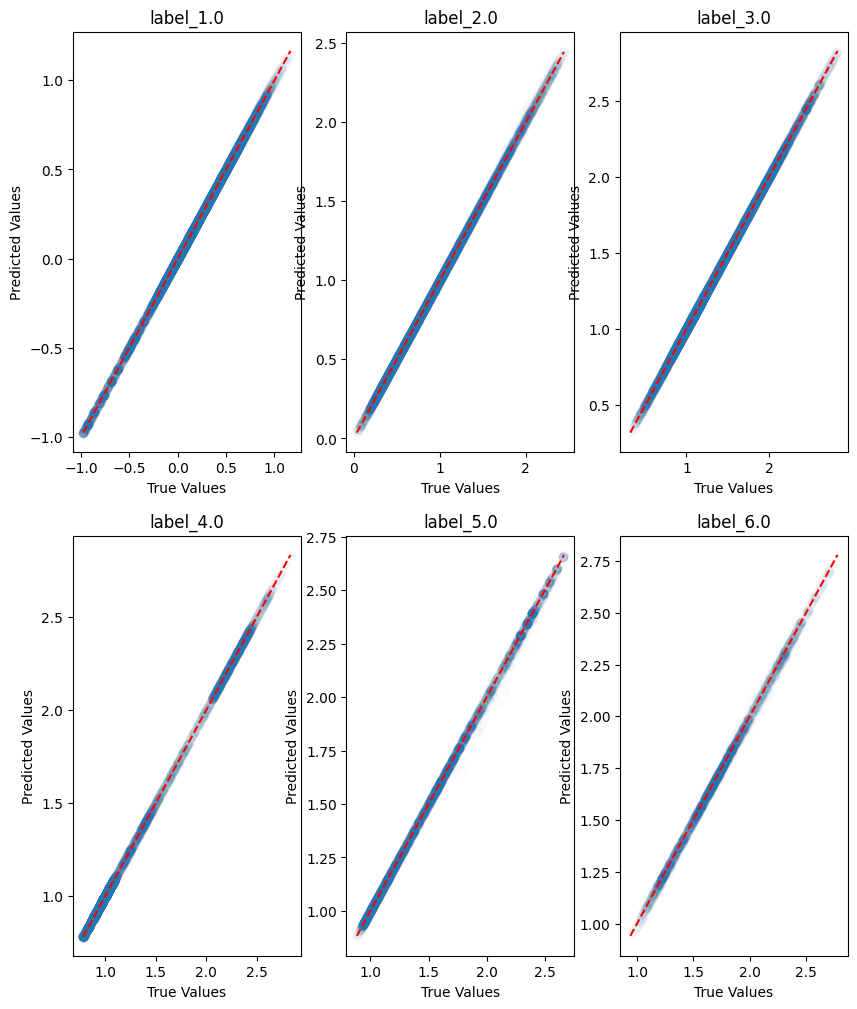

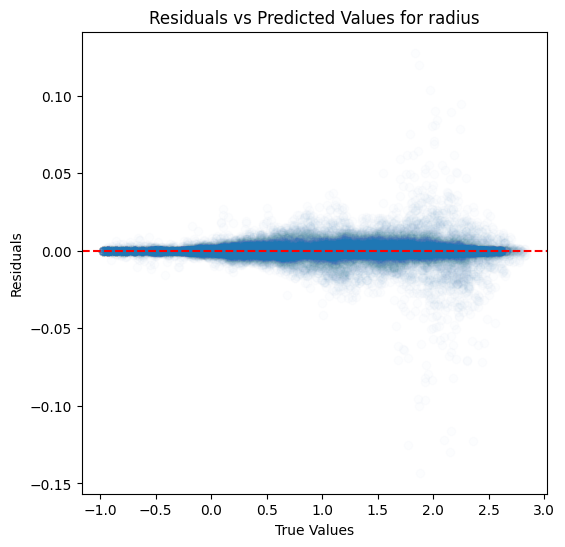

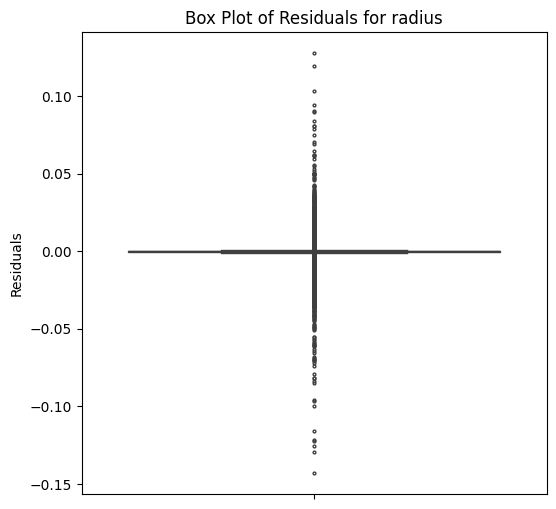

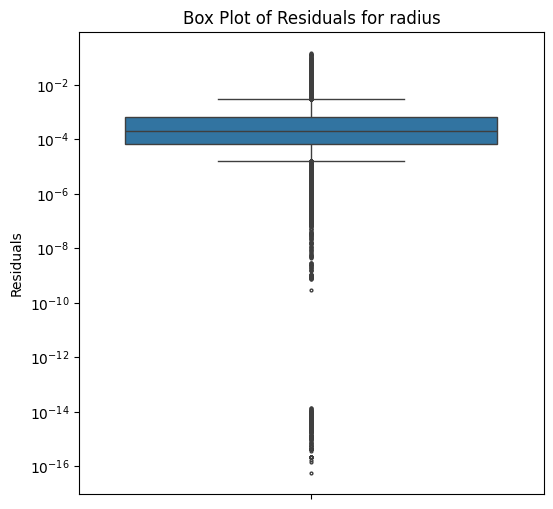

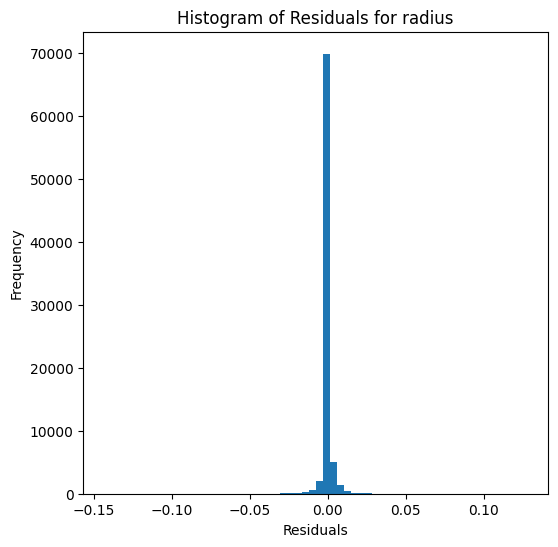

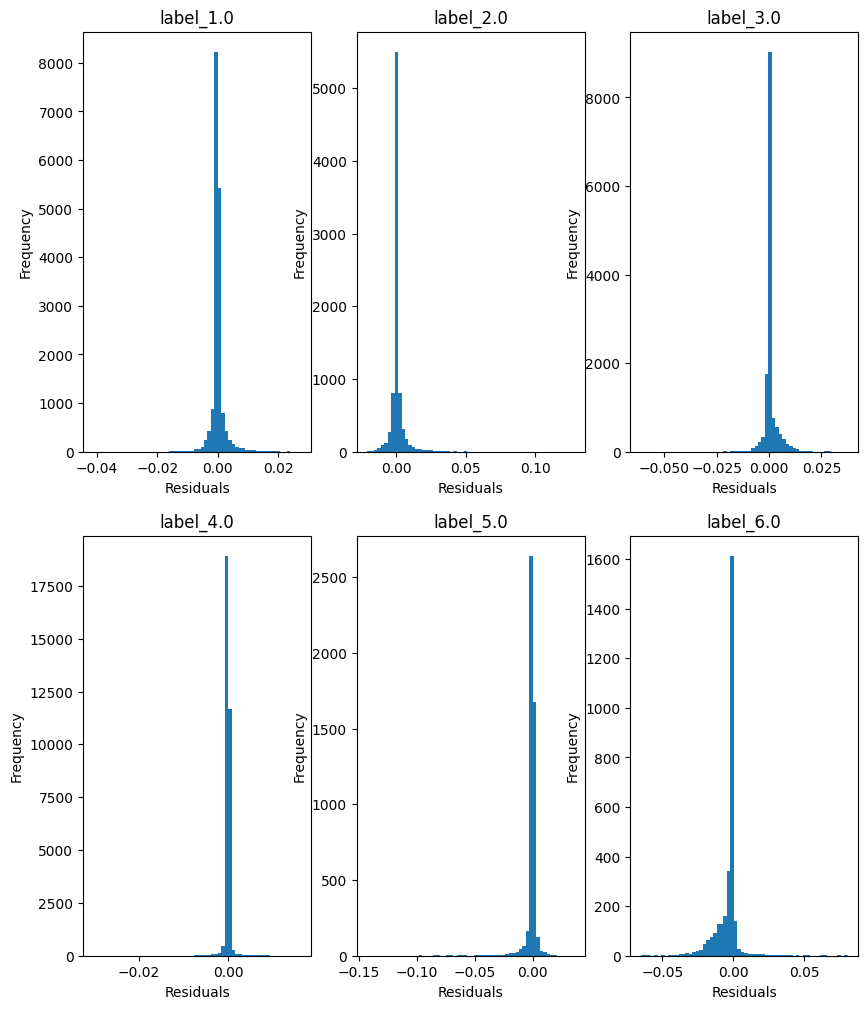

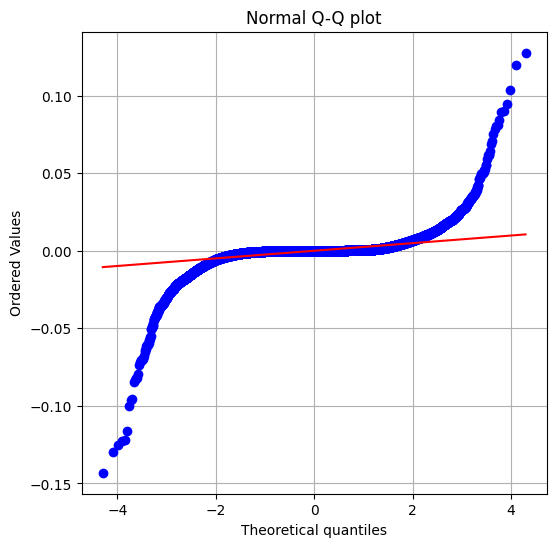

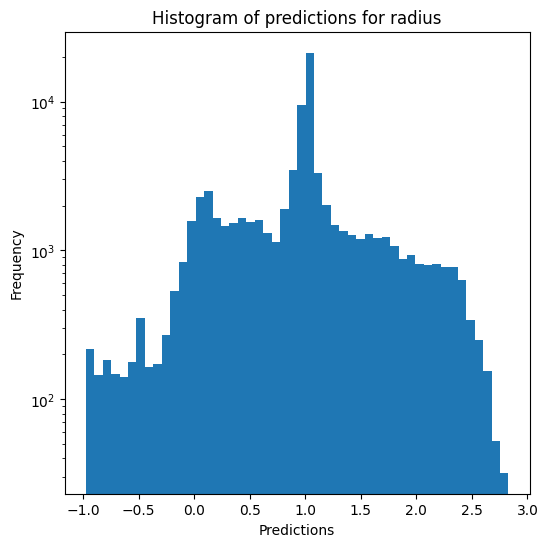

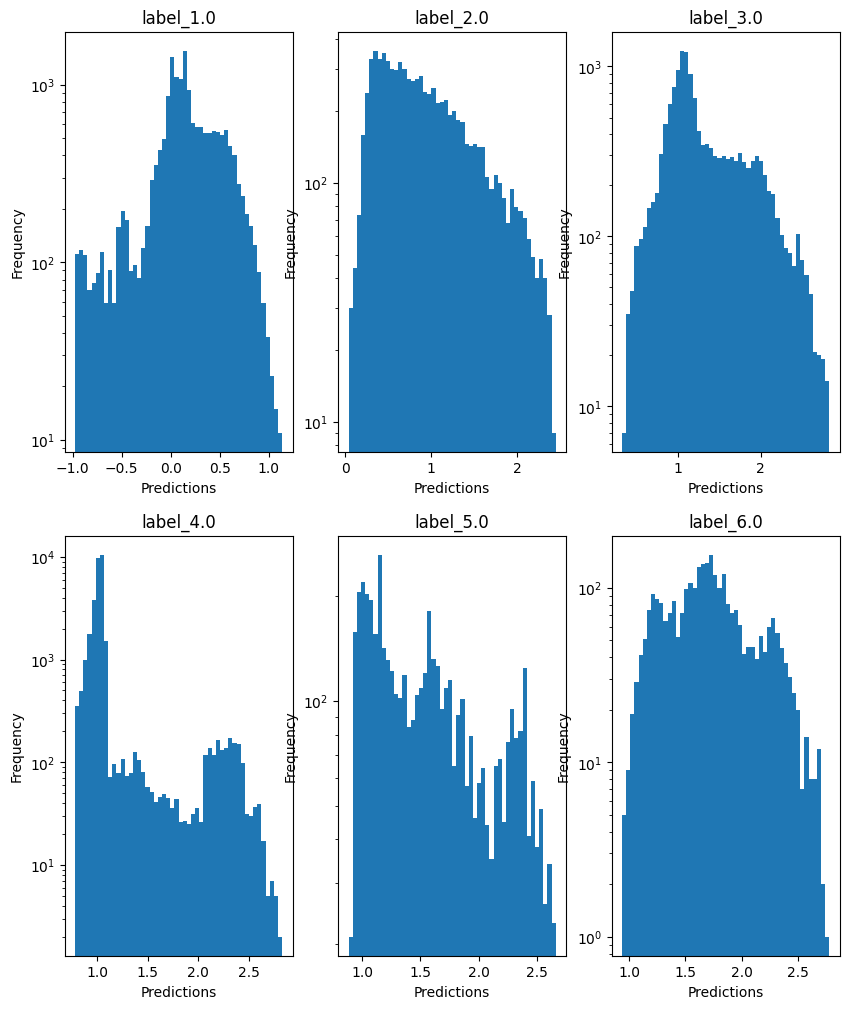

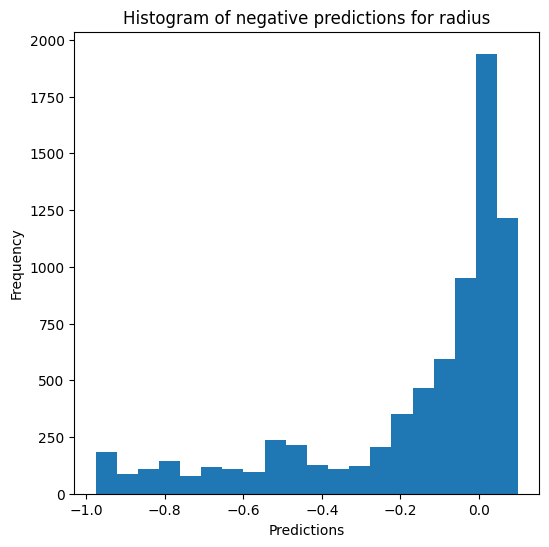

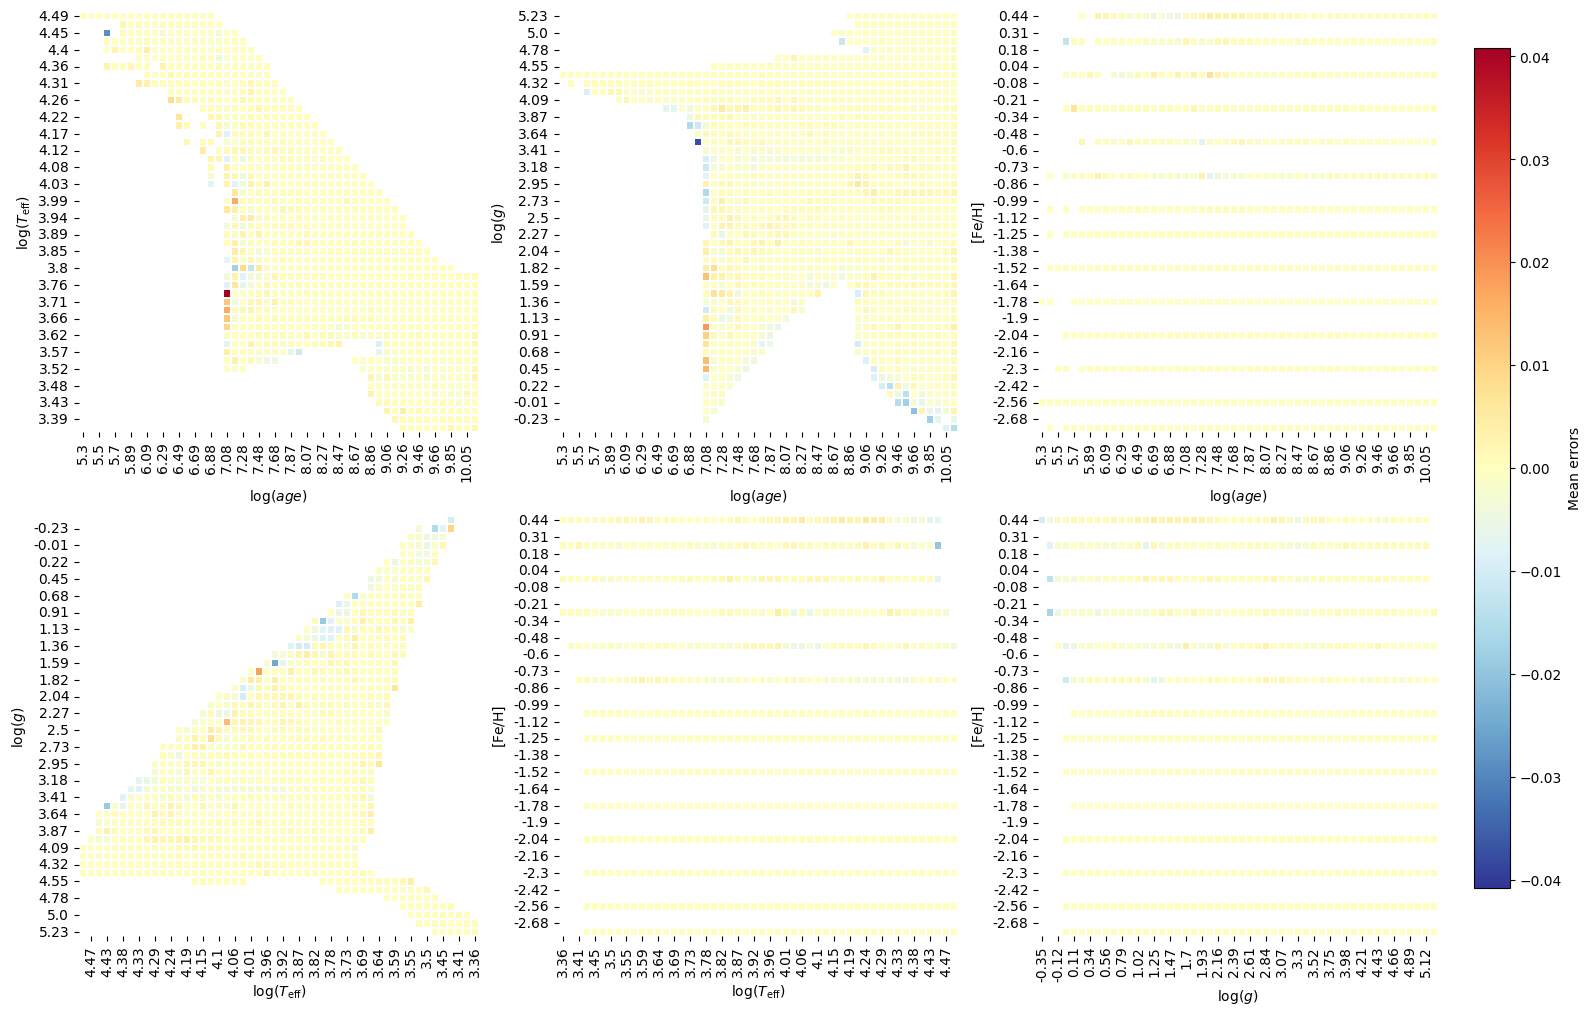

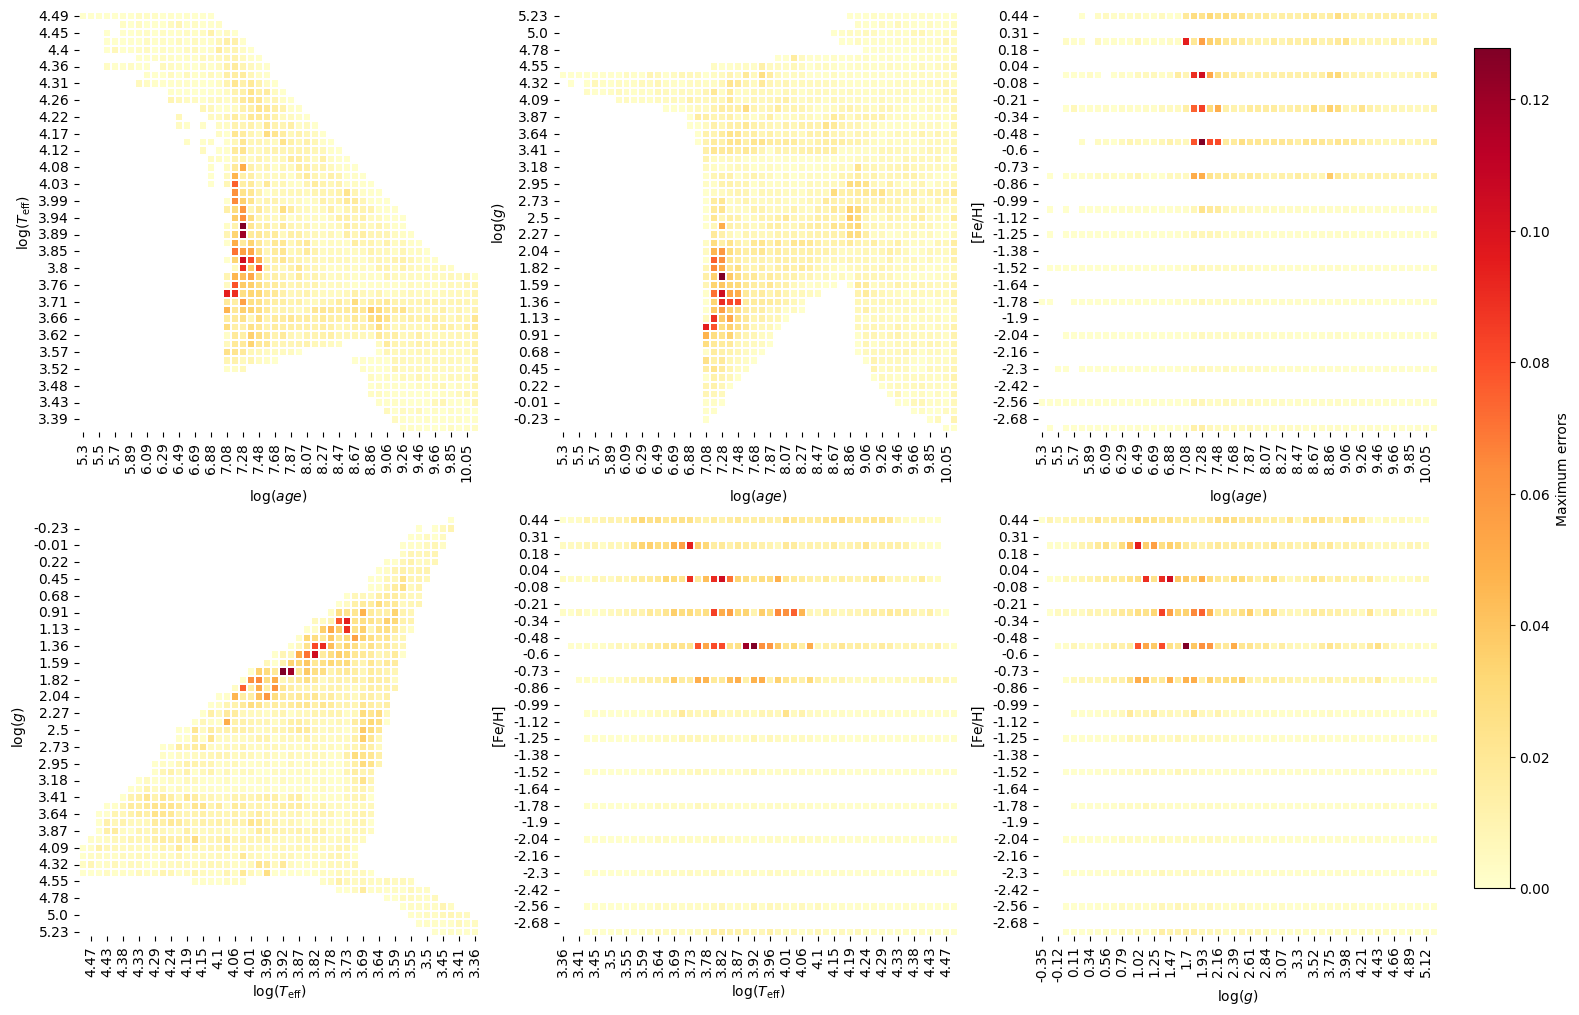

Saving results...


In [11]:
best_params_RF = {'n_jobs':10, 'n_estimators': 400, 'criterion': 'squared_error', 'max_depth': 100, 'min_samples_leaf': 1, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_leaf_nodes': None}

evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)
evaluator.evaluate_ivs_results(RandomForestRegressor, X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs, categories_name, 
                               path_to_predictions, tag, override=override, use_preds=use_preds, save=save, show=show, 
                               inputs=X_ivs, inputs_col_names=input_col_names, output_col_names=output_col_names, **best_params_RF)

## KNN (not used)

In [8]:
tag = "scale_standard"

In [10]:
best_params_KNN = {'n_jobs':10, 'algorithm': 'kd_tree', 'leaf_size': 100, 'n_neighbors': 5, 'p': 1.3, 'weights': 'distance'}

evaluator = Model_evaluator("KNN", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)
evaluator.evaluate_ivs_results(KNeighborsRegressor, X_train_standard, X_ivs_standard, y_train, y_ivs, categories_train, categories_ivs, categories_name, 
                               path_to_predictions, tag, override=True, use_preds=False, save=True, show=True, 
                               inputs=X_ivs, inputs_col_names=['logAge', 'logTe', 'logg', 'metallicity'], output_col_names=['Mass', 'Rpol'], **best_params_KNN)


scale_standard train data :


FileNotFoundError: ../../../../../../predictions/model_A_partial/final_models/KNN/PARSEC/scale_standard_inputs.npy not found.

## Decision tree

In [12]:
tag = "scale_quantile"


scale_quantile train data :
Evaluating predictions...
0.0


c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)



mass results for the label category with a value of 1.0
  value range :  0.09 - 13.952
  RVE :  0.9996522130664091
  RMSE :  0.05703634885556544
  MAE :  0.013024372002105353
  MedAE :  0.0
  CORR :  0.9998265091124922
  MAX_ER :  1.1130000000000013
  Percentiles : 
    75th percentile :  0.0010000000000000009
    90th percentile :  0.020999999999999908
    95th percentile :  0.06699999999999899
    99th percentile :  0.27549000000000123

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.9999640694703457
  RMSE :  0.01980238867859827
  MAE :  0.0057846441947565904
  MedAE :  0.0
  CORR :  0.9999820445041052
  MAX_ER :  0.36299999999999955
  Percentiles : 
    75th percentile :  0.0009999999999994458
    90th percentile :  0.017999999999999794
    95th percentile :  0.040999999999999925
    99th percentile :  0.08999999999999986

mass results for the label category with a value of 3.0
  value range :  0.655 - 13.902
  RVE :  0.9999164964

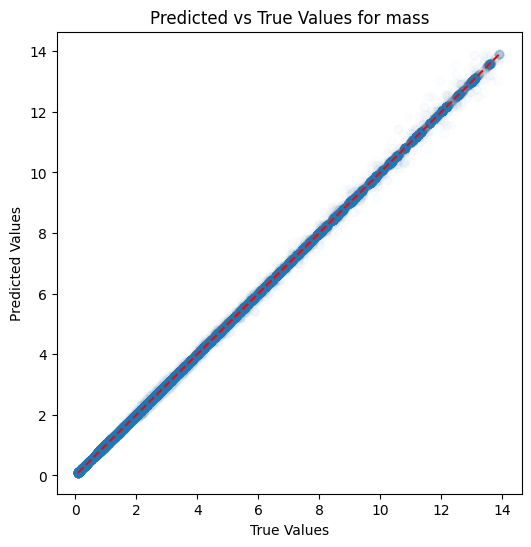

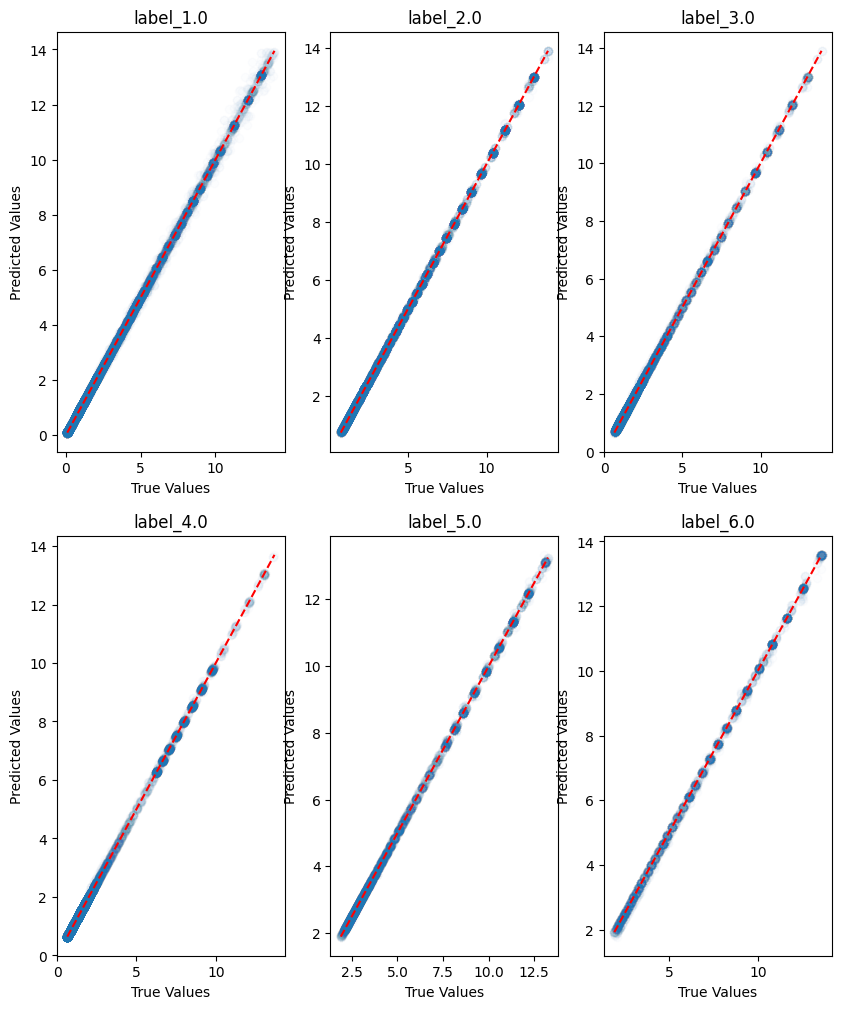

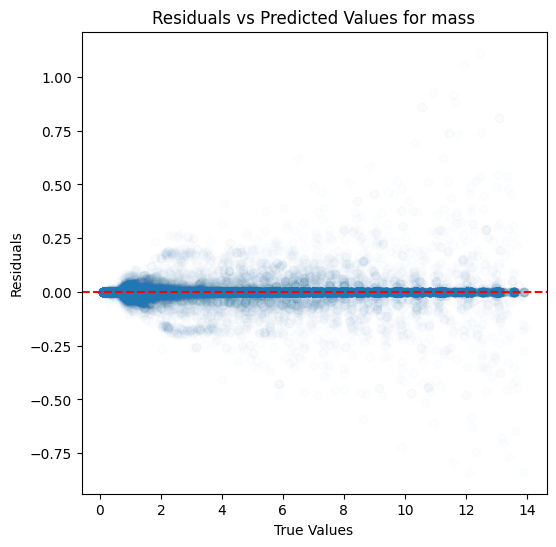

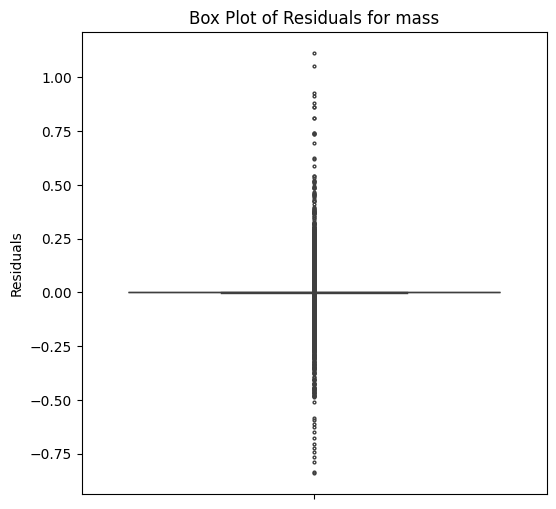

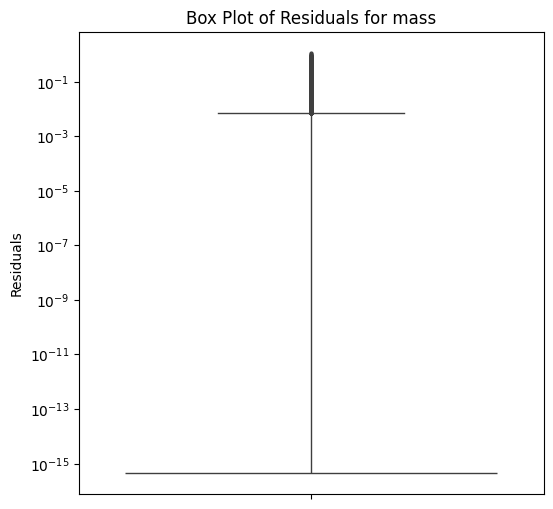

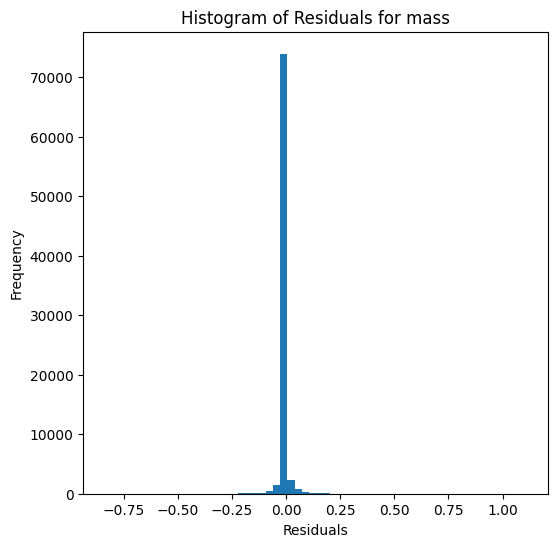

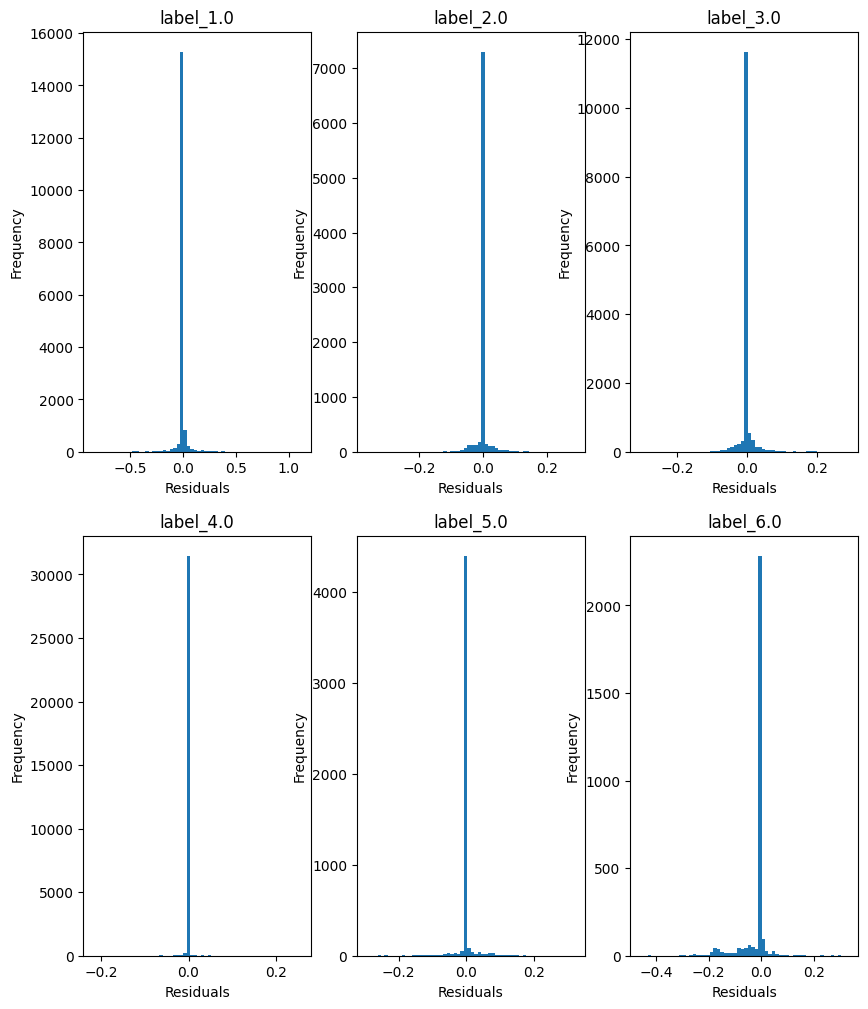

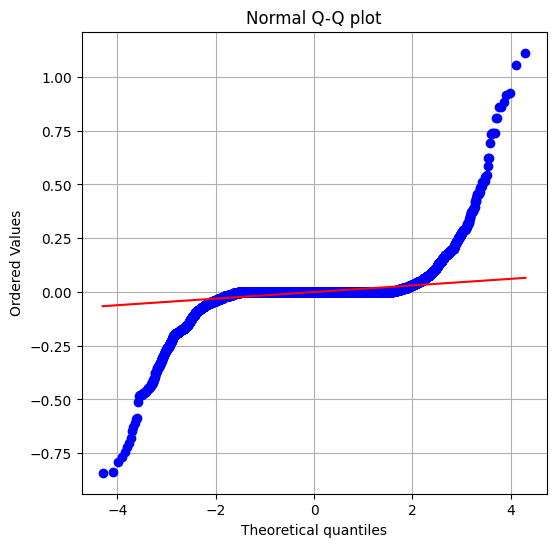

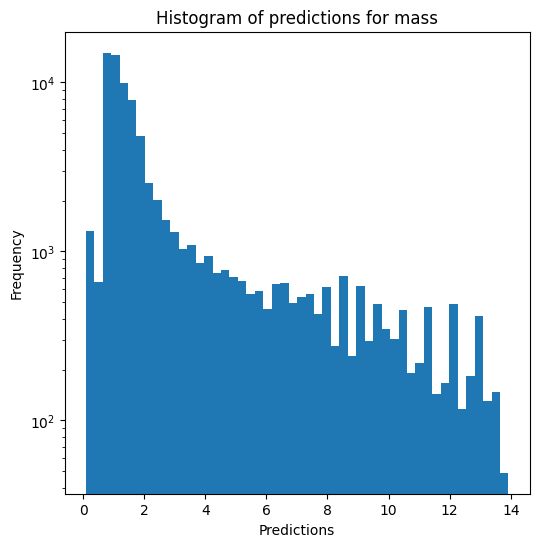

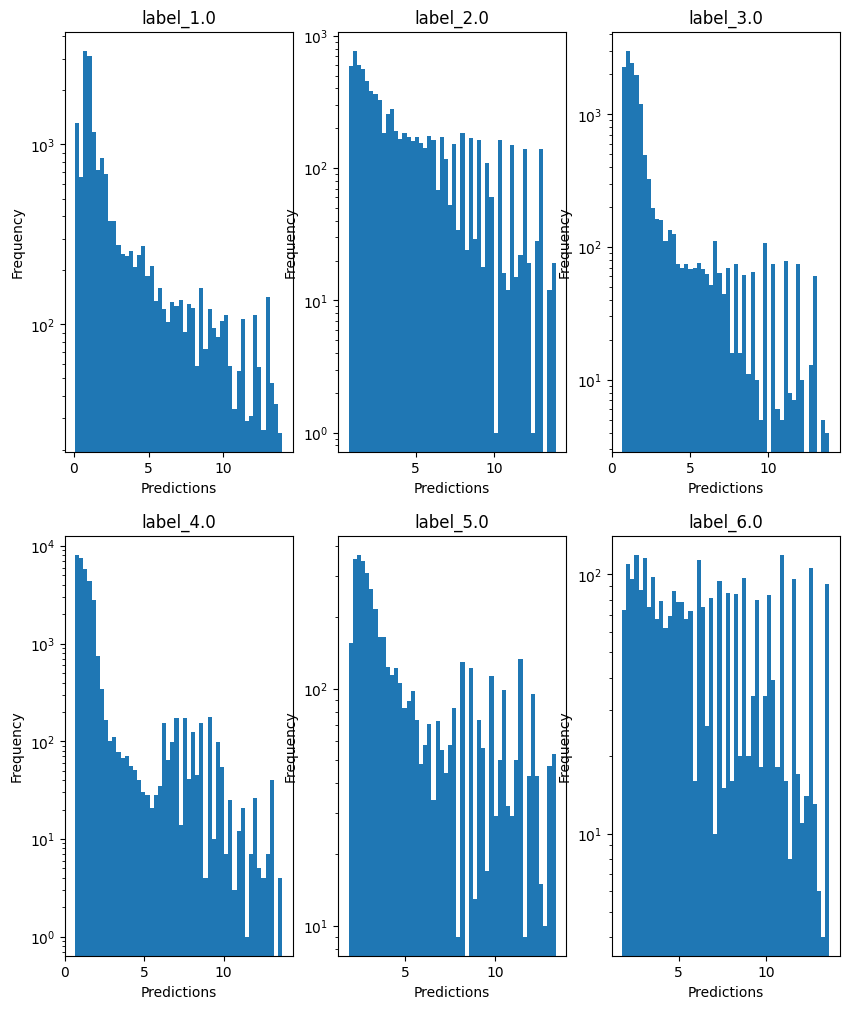

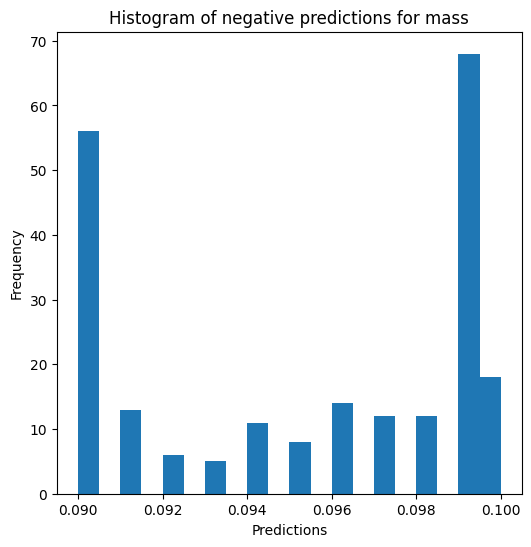

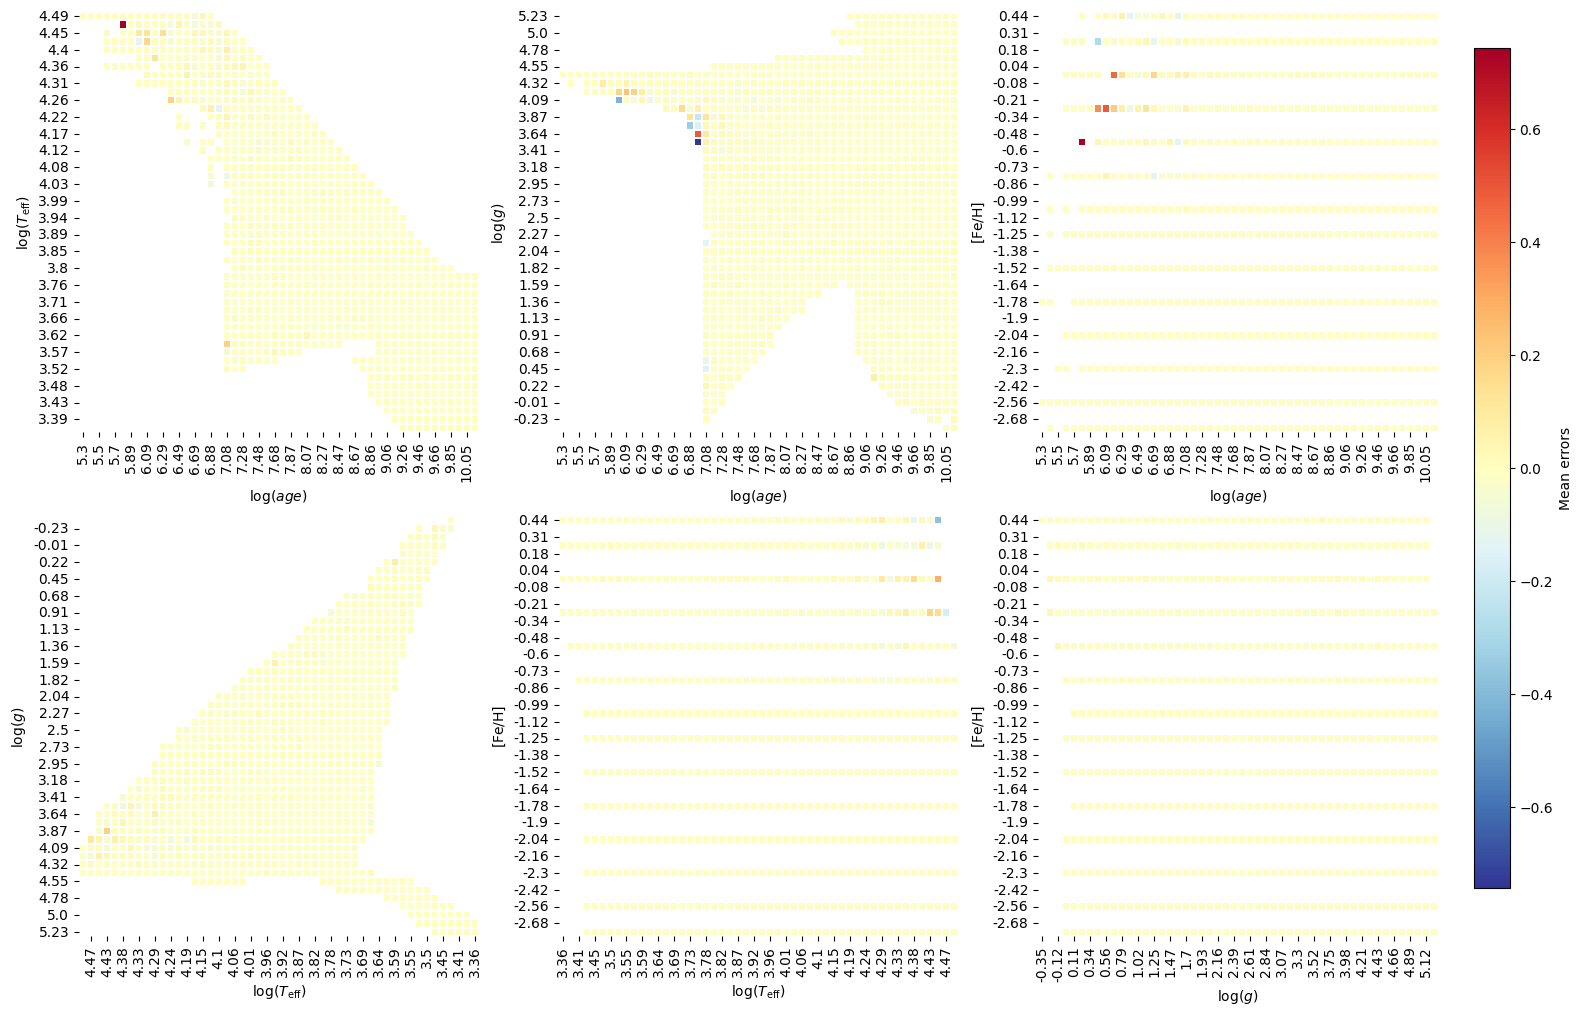

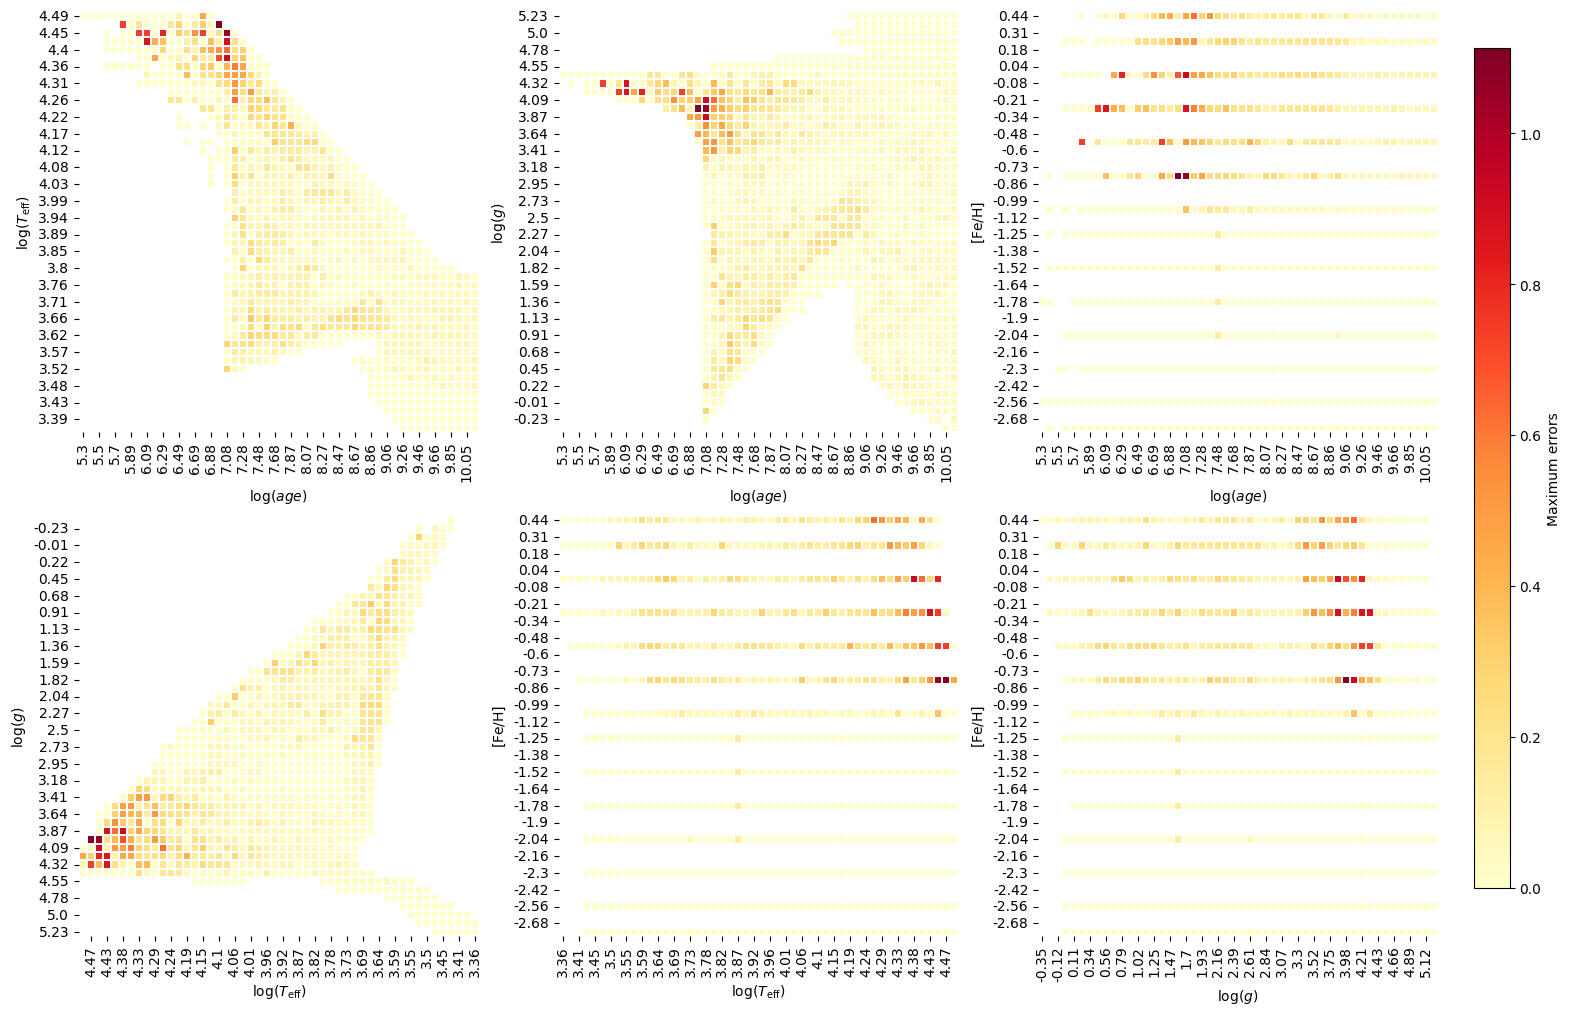

0.0


c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)



radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.165244326125311
  RVE :  0.9996947615036043
  RMSE :  0.006437674066749243
  MAE :  0.0024188646309062653
  MedAE :  5.551115123125783e-17
  CORR :  0.9998474762714623
  MAX_ER :  0.08805007529244135
  Percentiles : 
    75th percentile :  0.0017043564958996726
    90th percentile :  0.007291381636893099
    95th percentile :  0.013259781302955085
    99th percentile :  0.03055221534261978

radius results for the label category with a value of 2.0
  value range :  0.0366288953621611 - 2.443262987458695
  RVE :  0.999435637885448
  RMSE :  0.012858790972716527
  MAE :  0.005089910743230816
  MedAE :  0.0
  CORR :  0.999720237790037
  MAX_ER :  0.28026682367506917
  Percentiles : 
    75th percentile :  0.00629009496995292
    90th percentile :  0.01822701906071226
    95th percentile :  0.023975681603928097
    99th percentile :  0.039937086408785516

radius results for the label category

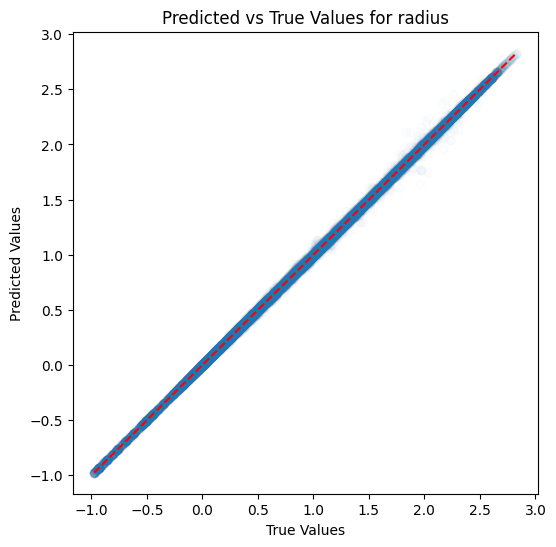

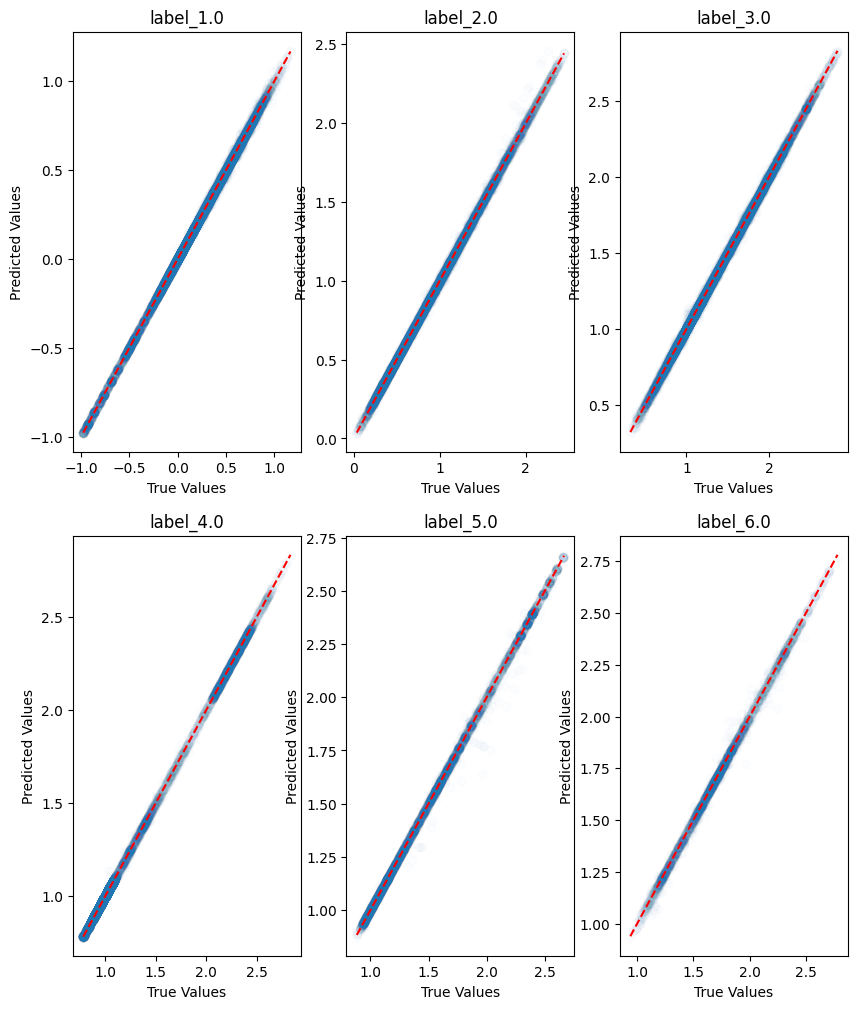

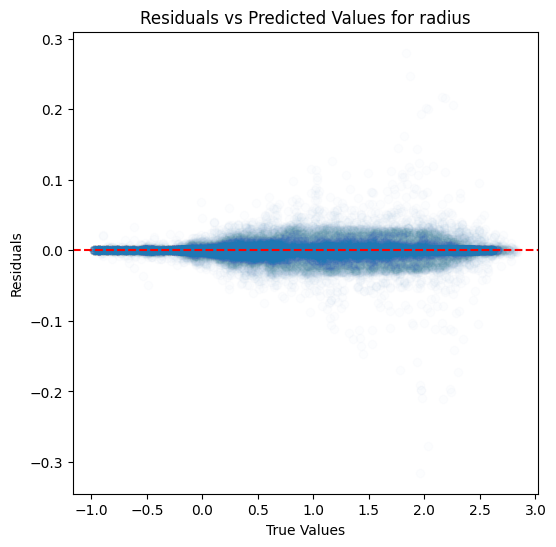

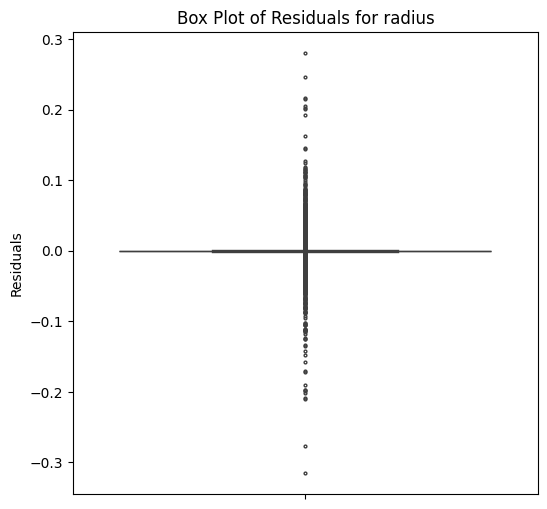

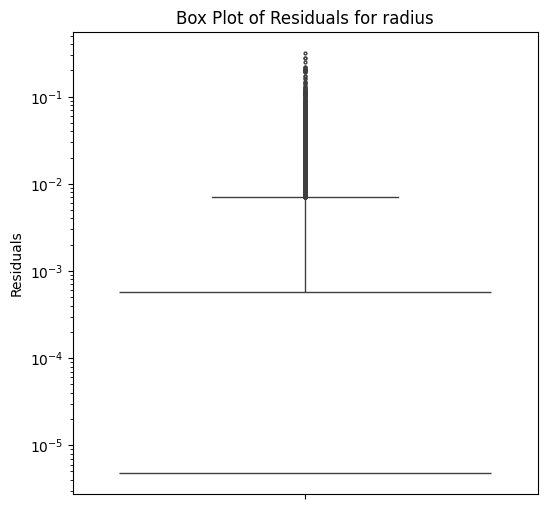

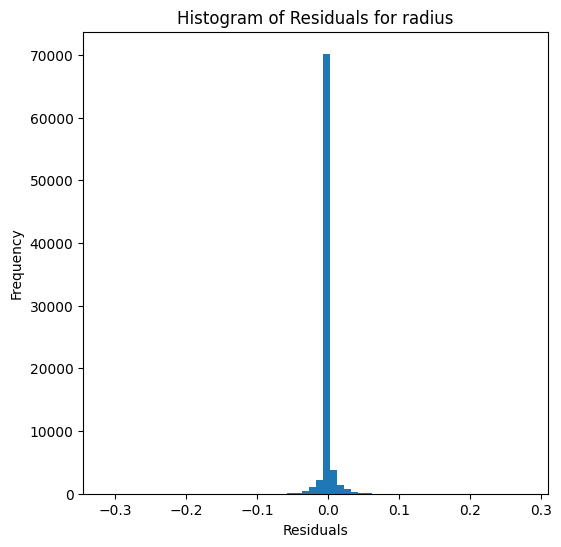

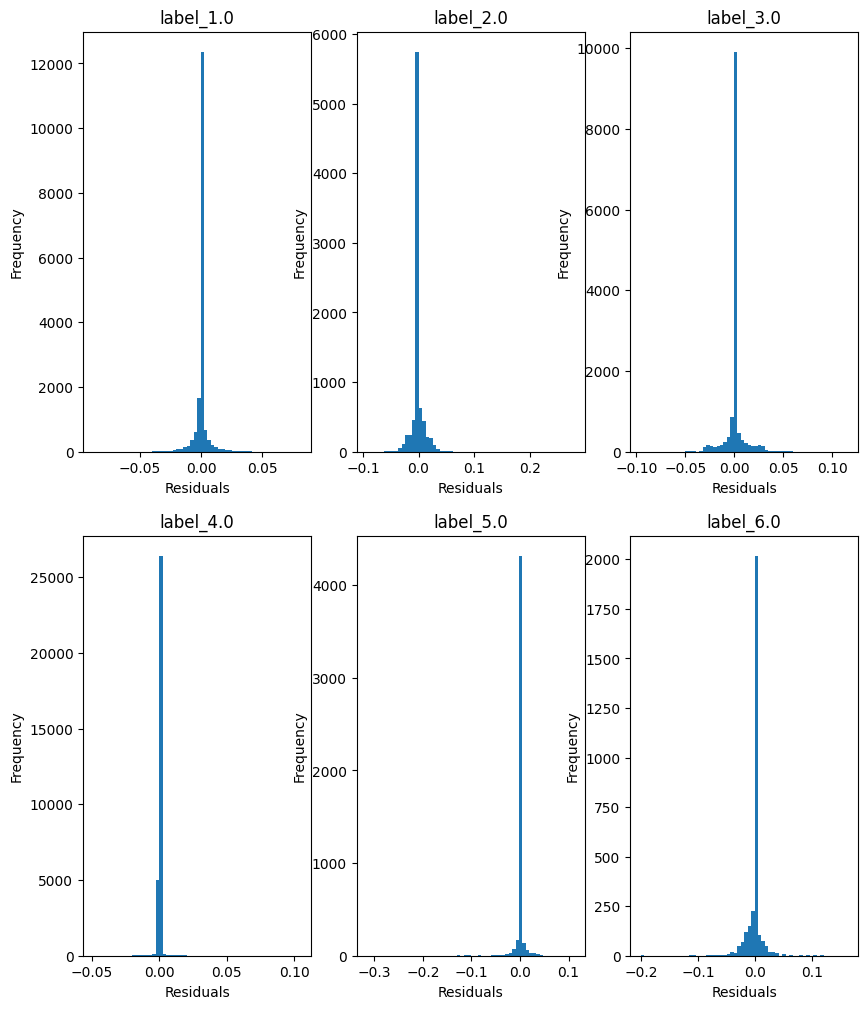

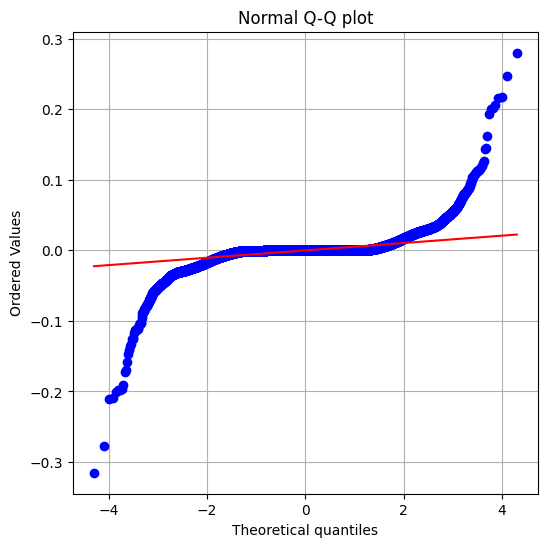

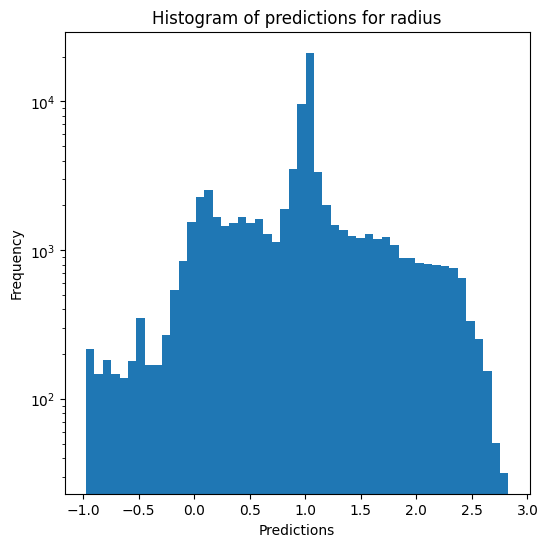

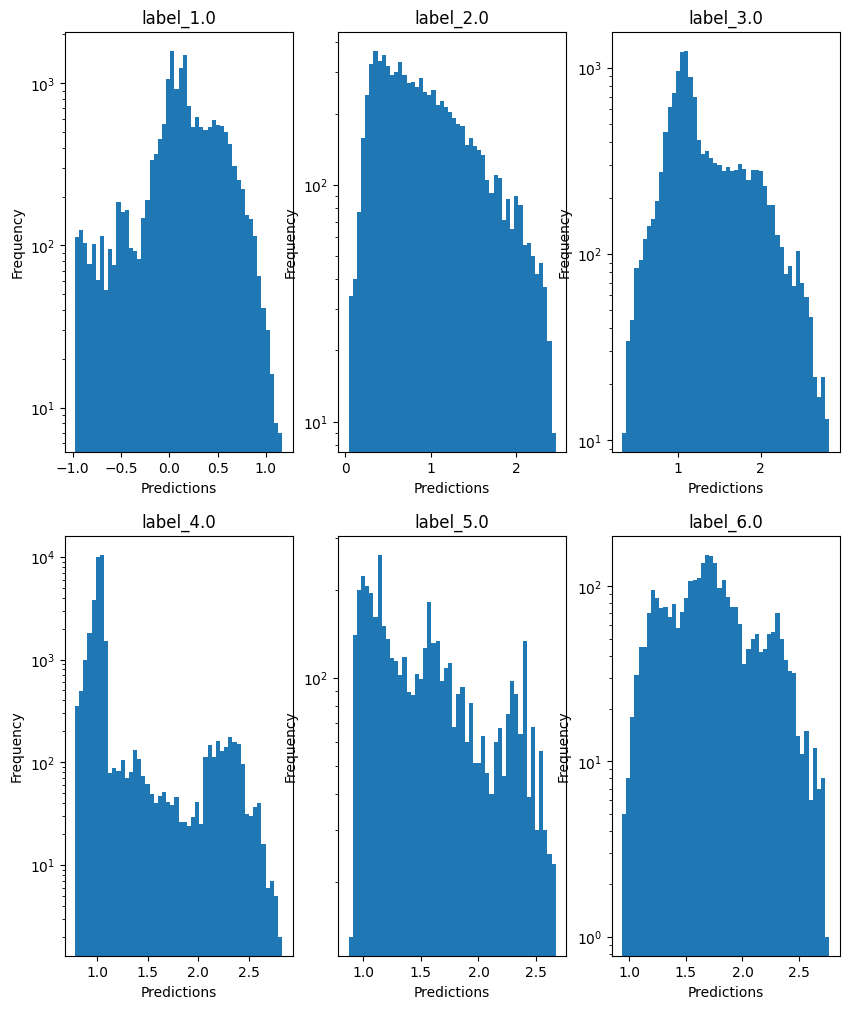

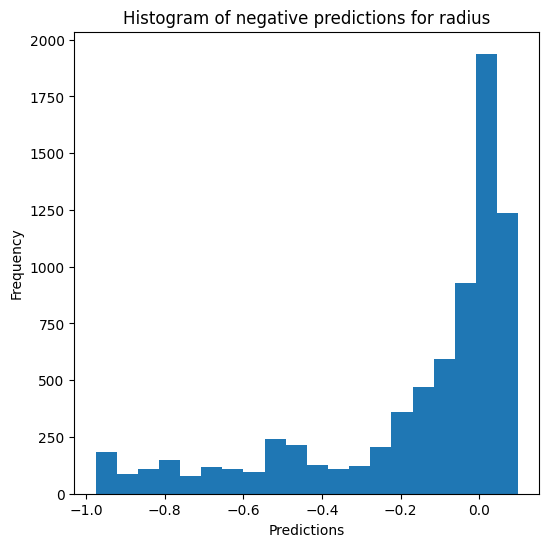

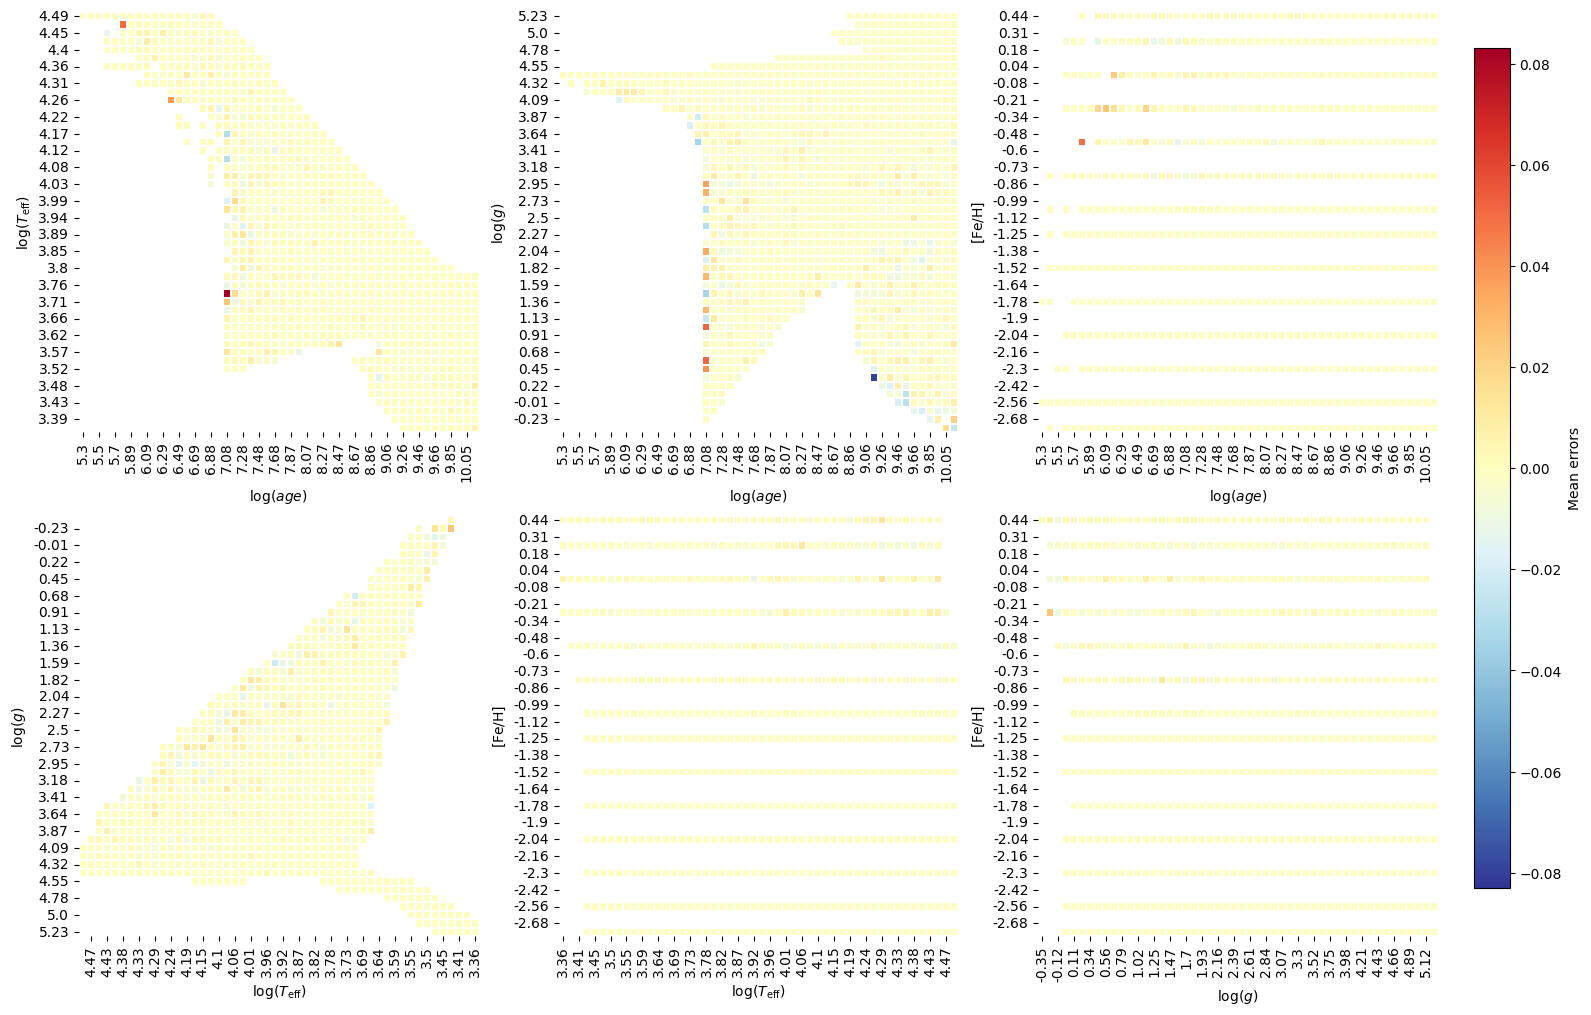

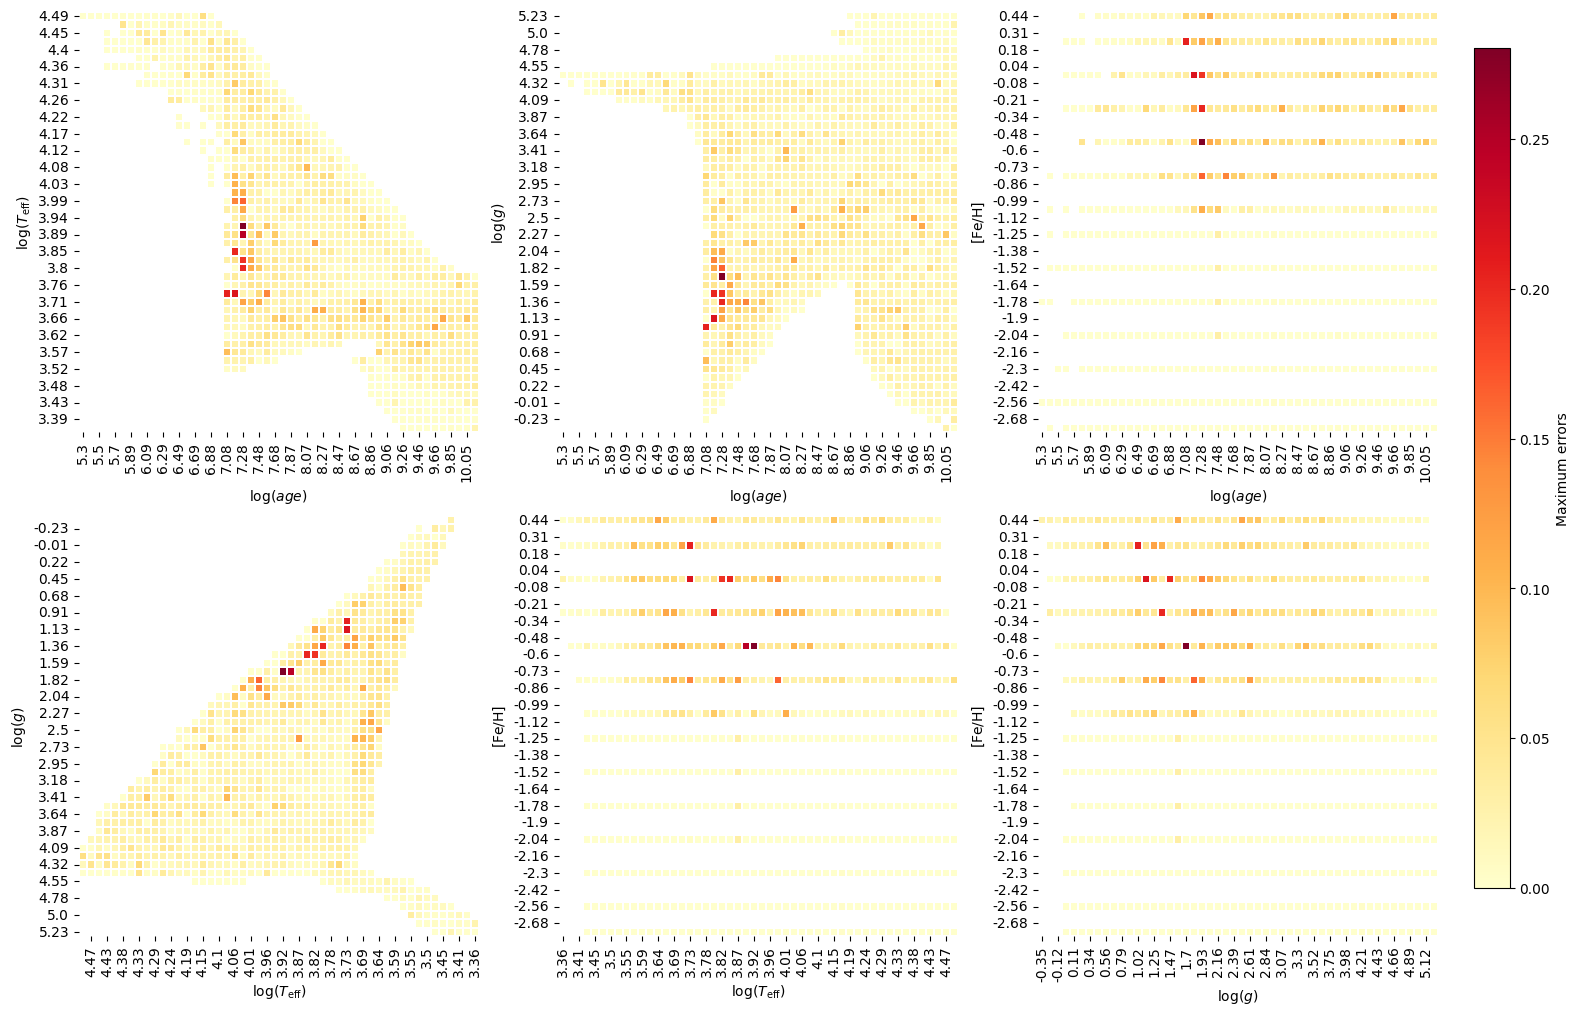

Saving results...


In [13]:
best_params_DT = {'criterion': 'squared_error', 'splitter': "best", 'max_depth': 75, 'min_samples_leaf': 1, 'min_samples_split': 2, 'max_features': None, 'max_leaf_nodes': None}

evaluator = Model_evaluator("decision_tree", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)
evaluator.evaluate_ivs_results(DecisionTreeRegressor, X_train_quantile, X_ivs_quantile, y_train, y_ivs, categories_train, categories_ivs, categories_name, 
                               path_to_predictions, tag, override=override, use_preds=use_preds, save=save, show=show, 
                               inputs=X_ivs, inputs_col_names=input_col_names, output_col_names=output_col_names, **best_params_DT)

# Training the final models

In [25]:
X = np.append(X_train, X_ivs, 0)
X_standard = np.append(X_train_standard, X_ivs_standard, 0)
X_quantile = np.append(X_train_quantile, X_ivs_quantile, 0)
y = np.append(y_train, y_ivs, 0)

print(X.shape)
print(X_standard.shape)
print(X_quantile.shape)
print(y.shape)

(321696, 4)
(321696, 4)
(321696, 4)
(321696, 2)


## Random forest

### Final model with fine-tuned parameters

In [ ]:
best_params_RF = {'n_jobs':10, 'n_estimators': 400, 'criterion': 'squared_error', 'max_depth': 100, 'min_samples_leaf': 1, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_leaf_nodes': None}

mdl = RandomForestRegressor(**best_params_RF)
mdl.fit(X, y)

,n_estimators,400
,criterion,'squared_error'
,max_depth,100
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
joblib.dump(mdl, pre_path + path_to_models + "RF_compress_0.pkl", compress=0)
# 7.3 GB, 1.82 GB après zip
# 11.8 secondes pour créé le fichier

['../../../../../../model/final_models/Model_A_partial_PARSEC_RF_compress_0.pkl']

In [ ]:
joblib.dump(mdl, pre_path + path_to_models + 'test_RF.pkl.z')
# 1.92 GB
# 1 minutes 30 pour créé le fichier

['../../../../../../model/final_models/test_Model_A_partial_PARSEC_RF.pkl.z']

In [ ]:
joblib.dump(mdl, pre_path + path_to_models + "RF_compress_3.pkl", compress=3)
# 1.92 GB
# 1 minutes 30 pour créé le fichier

['../../../../../../model/final_models/Model_A_partial_PARSEC_RF_compress_3.pkl']

## KNN

In [ ]:
best_params_KNN = {'n_jobs':10, 'algorithm': 'kd_tree', 'leaf_size': 100, 'n_neighbors': 5, 'p': 1.3, 'weights': 'distance'}

mdl = KNeighborsRegressor(**best_params_KNN)
mdl.fit(X_standard, y)

,n_neighbors,5
,weights,'distance'
,algorithm,'kd_tree'
,leaf_size,100
,p,1.3
,metric,'minkowski'
,metric_params,None
,n_jobs,10


In [ ]:
joblib.dump(mdl, pre_path + path_to_models + "KNN_compress_0.pkl", compress=0)
# 0.0 secondes
# 28 MB

['../../../../../../model/final_models/Model_A_partial/PARSEC/KNN_compress_0.pkl']

## Decision tree

In [26]:
best_params_DT = {'criterion': 'squared_error', 'splitter': "best", 'max_depth': 75, 'min_samples_leaf': 1, 'min_samples_split': 2, 'max_features': None, 'max_leaf_nodes': None}

mdl = DecisionTreeRegressor(**best_params_DT)
mdl.fit(X_quantile, y)

,criterion,'squared_error'
,splitter,'best'
,max_depth,75
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [27]:
joblib.dump(mdl, pre_path + path_to_models + "DT_compress_0.pkl", compress=0)
# 0.0 secondes
# 10 MB

['../../../../../../model/final_models/Model_A_partial/PARSEC/DT_compress_0.pkl']